# 📈 Analisis Swing Trading Saham

> **Cara Pakai:** Cukup ubah `TICKER` di cell berikutnya, lalu **Run All**. Semua analisis otomatis menyesuaikan.

---

In [1]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ⚙️  KONFIGURASI — UBAH DI SINI SAJA                       ║
# ╚══════════════════════════════════════════════════════════════╝

TICKER = "KAQI.JK"          # 🔄 Ganti ticker di sini (contoh: BBRI.JK, TLKM.JK, ASII.JK, AAPL)
PERIOD = "1y"                # Periode data: 6mo, 1y, 2y, 5y, max
INTERVAL = "1d"              # Interval: 1d (harian) untuk swing trading

# --- Parameter Indikator (opsional, sudah default bagus) ---
EMA_FAST     = 20            # EMA cepat
EMA_SLOW     = 50            # EMA lambat
SMA_LONG     = 200           # SMA tren jangka panjang
RSI_PERIOD   = 14            # RSI period
RSI_OB       = 70            # RSI overbought
RSI_OS       = 30            # RSI oversold
MACD_FAST    = 12            # MACD fast
MACD_SLOW    = 26            # MACD slow
MACD_SIGNAL  = 9             # MACD signal
BB_PERIOD    = 20            # Bollinger Bands period
BB_STD       = 2             # Bollinger Bands std dev
VOL_MA       = 20            # Moving average volume
SR_MAX_DIST_PCT = 0.15       # Maks jarak S/R dari harga saat ini (15%)

# --- Output ---
import os
OUTPUT_DIR = f"outputs/swing/{TICKER.replace('.', '_')}"
FIG_DIR    = f"{OUTPUT_DIR}/figures"
os.makedirs(FIG_DIR, exist_ok=True)

print(f"✅ Konfigurasi siap — Analisis: {TICKER} | Periode: {PERIOD} | Interval: {INTERVAL}")

✅ Konfigurasi siap — Analisis: KAQI.JK | Periode: 1y | Interval: 1d


In [2]:
# ============================================================
# 1) INSTALL & IMPORT
# ============================================================
import subprocess, sys
for pkg in ["yfinance", "pandas", "numpy", "matplotlib", "mplfinance", "pandas_ta", "scipy"]:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

import warnings; warnings.filterwarnings("ignore")
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import mplfinance as mpf
from scipy.signal import argrelextrema
from datetime import datetime

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 150, 'font.size': 10})

print("✅ Semua library siap.")

✅ Semua library siap.


In [3]:
# ============================================================
# 2) DOWNLOAD DATA & INFO SAHAM
# ============================================================

stock = yf.Ticker(TICKER)
df = stock.history(period=PERIOD, interval=INTERVAL)

# Flatten MultiIndex jika ada
if isinstance(df.columns, pd.MultiIndex):
    df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]

# Bersihkan
df = df[['Open', 'High', 'Low', 'Close', 'Volume']].dropna()
df.index = pd.to_datetime(df.index)
if df.index.tz is not None:
    df.index = df.index.tz_localize(None)

# Info perusahaan
info = stock.info
company_name = info.get('longName', info.get('shortName', TICKER))
sector = info.get('sector', '-')
industry = info.get('industry', '-')
market_cap = info.get('marketCap', 0)
currency = info.get('currency', 'IDR')

print(f"{'═' * 60}")
print(f"  📊 {company_name} ({TICKER})")
print(f"{'═' * 60}")
print(f"  🏢 Sektor    : {sector}")
print(f"  🏭 Industri  : {industry}")
print(f"  💰 Market Cap: {currency} {market_cap:,.0f}" if market_cap else "  💰 Market Cap: N/A")
print(f"  📅 Data      : {df.index[0].strftime('%Y-%m-%d')} → {df.index[-1].strftime('%Y-%m-%d')}")
print(f"  📈 Candles   : {len(df):,} hari")
print(f"  💵 Harga saat ini: {currency} {df['Close'].iloc[-1]:,.2f}")
print(f"{'═' * 60}")
df.tail(3)

════════════════════════════════════════════════════════════
  📊 Jantra Grupo Indonesia Tbk. (KAQI.JK)
════════════════════════════════════════════════════════════
  🏢 Sektor    : Consumer Cyclical
  🏭 Industri  : Auto Parts
  💰 Market Cap: IDR 244,944,404,480
  📅 Data      : 2025-03-10 → 2026-03-02
  📈 Candles   : 231 hari
  💵 Harga saat ini: IDR 118.00
════════════════════════════════════════════════════════════


,Open,High,Low,Close,Volume
Date,,,,,
2026-02-26,113.00,133.00,104.00,124.00,2286376700
2026-02-27,114.00,115.00,106.00,110.00,427971700
2026-03-02,109.00,139.00,97.00,118.00,1504782100


In [4]:
# ============================================================
# 3) HITUNG SEMUA INDIKATOR TEKNIKAL
# ============================================================

# --- Moving Averages ---
df['EMA_fast'] = df['Close'].ewm(span=EMA_FAST, adjust=False).mean()
df['EMA_slow'] = df['Close'].ewm(span=EMA_SLOW, adjust=False).mean()
df['SMA_long'] = df['Close'].rolling(SMA_LONG).mean()

# --- RSI ---
delta = df['Close'].diff()
gain = delta.where(delta > 0, 0).rolling(RSI_PERIOD).mean()
loss = (-delta.where(delta < 0, 0)).rolling(RSI_PERIOD).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

# --- MACD ---
ema_f = df['Close'].ewm(span=MACD_FAST, adjust=False).mean()
ema_s = df['Close'].ewm(span=MACD_SLOW, adjust=False).mean()
df['MACD']        = ema_f - ema_s
df['MACD_Signal'] = df['MACD'].ewm(span=MACD_SIGNAL, adjust=False).mean()
df['MACD_Hist']   = df['MACD'] - df['MACD_Signal']

# --- Bollinger Bands ---
df['BB_Mid']   = df['Close'].rolling(BB_PERIOD).mean()
bb_std         = df['Close'].rolling(BB_PERIOD).std()
df['BB_Upper'] = df['BB_Mid'] + BB_STD * bb_std
df['BB_Lower'] = df['BB_Mid'] - BB_STD * bb_std
df['BB_Width'] = (df['BB_Upper'] - df['BB_Lower']) / df['BB_Mid'] * 100
df['BB_Pct']   = (df['Close'] - df['BB_Lower']) / (df['BB_Upper'] - df['BB_Lower'])

# --- Volume Analysis ---
df['Vol_MA']    = df['Volume'].rolling(VOL_MA).mean()
df['Vol_Ratio'] = df['Volume'] / df['Vol_MA']

# --- ATR (Average True Range) untuk volatilitas ---
high_low  = df['High'] - df['Low']
high_prev = abs(df['High'] - df['Close'].shift(1))
low_prev  = abs(df['Low']  - df['Close'].shift(1))
tr = pd.concat([high_low, high_prev, low_prev], axis=1).max(axis=1)
df['ATR'] = tr.rolling(14).mean()
df['ATR_Pct'] = df['ATR'] / df['Close'] * 100

# --- Stochastic RSI ---
rsi_min = df['RSI'].rolling(14).min()
rsi_max = df['RSI'].rolling(14).max()
df['StochRSI']   = (df['RSI'] - rsi_min) / (rsi_max - rsi_min)
df['StochRSI_K'] = df['StochRSI'].rolling(3).mean()
df['StochRSI_D'] = df['StochRSI_K'].rolling(3).mean()

# ══════════════════════════════════════════════════════════════
# Support & Resistance (Advanced: Multi-Scale Pivot + Clustering)
# ══════════════════════════════════════════════════════════════
current_price = df['Close'].iloc[-1]
recent = df.copy()
df_sr  = recent.reset_index(drop=True)

# 1) Multi-scale pivot detection
all_resistances = []
all_supports    = []
for sr_ord in [3, 5, 8, 13, 21]:
    if sr_ord >= len(df_sr) // 3:
        continue
    max_idx = argrelextrema(df_sr['High'].values, np.greater_equal, order=sr_ord)[0]
    min_idx = argrelextrema(df_sr['Low'].values,  np.less_equal,    order=sr_ord)[0]
    all_resistances.extend(df_sr['High'].iloc[max_idx].tolist())
    all_supports.extend(df_sr['Low'].iloc[min_idx].tolist())

# Tambah period high/low sebagai anchor
all_resistances.append(float(recent['High'].max()))
all_supports.append(float(recent['Low'].min()))

# 2) Clustering (1.5% toleransi)
def cluster_sr(levels, tol_pct, ref):
    if not levels:
        return []
    levels = sorted(levels)
    clusters, cur = [], [levels[0]]
    for v in levels[1:]:
        if abs(v - np.mean(cur)) / ref <= tol_pct:
            cur.append(v)
        else:
            clusters.append(cur)
            cur = [v]
    clusters.append(cur)
    return [(np.median(c), len(c)) for c in clusters]

res_cl = cluster_sr(all_resistances, 0.015, current_price)
sup_cl = cluster_sr(all_supports,    0.015, current_price)

# 3) Filter & ranking
resistance_candidates = sorted(
    [(round(float(lv), 2), int(n)) for lv, n in res_cl
     if lv > current_price * 1.003
     and (lv / current_price - 1) <= SR_MAX_DIST_PCT],
    key=lambda x: (-x[1], x[0])
)
resistance_levels = sorted([lv for lv, _ in resistance_candidates])[:5]

support_candidates = sorted(
    [(round(float(lv), 2), int(n)) for lv, n in sup_cl
     if lv < current_price * 0.997
     and (1 - lv / current_price) <= SR_MAX_DIST_PCT],
    key=lambda x: (-x[1], -x[0])
)
support_levels = sorted([lv for lv, _ in support_candidates])[:5]

# Fallback resistance
if len(resistance_levels) < 2:
    for p in [75, 90, 95]:
        lv = round(float(np.percentile(recent['High'], p)), 2)
        if lv > current_price * 1.003 and lv not in resistance_levels:
            resistance_levels.append(lv)
    resistance_levels = sorted(set(resistance_levels))[:5]

# Fallback support (percentile + ATR-based)
if len(support_levels) < 2:
    for p in [25, 10, 5]:
        lv = round(float(np.percentile(recent['Low'], p)), 2)
        if lv < current_price * 0.997 and lv not in support_levels:
            support_levels.append(lv)
    if len(support_levels) < 2 and df['ATR'].notna().any():
        avg_atr = float(df['ATR'].dropna().iloc[-20:].mean())
        for mult in [1, 1.5, 2, 3, 4]:
            lv = round(float(current_price - avg_atr * mult), 2)
            if lv > 0 and lv < current_price * 0.997 and lv not in support_levels:
                support_levels.append(lv)
    support_levels = sorted(set(support_levels))[:5]

# Touch count lookup
res_touch = {lv: n for lv, n in resistance_candidates}
sup_touch = {lv: n for lv, n in support_candidates}

# --- Output ---
print(f"✅ {len(df.columns)} kolom indikator dihitung.")
print(f"   📊 EMA {EMA_FAST}/{EMA_SLOW}, SMA {SMA_LONG}, RSI {RSI_PERIOD}, MACD, BB, ATR, StochRSI")
print(f"   💰 Harga saat ini: {current_price:,.0f}")
print(f"   🔺 Resistance ({len(resistance_levels)} level):")
for lv in resistance_levels:
    dist = (lv / current_price - 1) * 100
    t = res_touch.get(lv, 0)
    tag = f"{t}x sentuhan" if t > 0 else "fallback"
    print(f"      R: {lv:>12,.0f}  (↑{dist:+.1f}%, {tag})")
print(f"   🔻 Support ({len(support_levels)} level):")
for lv in support_levels:
    dist = (lv / current_price - 1) * 100
    t = sup_touch.get(lv, 0)
    tag = f"{t}x sentuhan" if t > 0 else "fallback"
    print(f"      S: {lv:>12,.0f}  (↓{dist:+.1f}%, {tag})")

✅ 24 kolom indikator dihitung.
   📊 EMA 20/50, SMA 200, RSI 14, MACD, BB, ATR, StochRSI
   💰 Harga saat ini: 118
   🔺 Resistance (0 level):
   🔻 Support (5 level):
      S:           50  (↓-57.6%, fallback)
      S:           76  (↓-35.2%, fallback)
      S:           87  (↓-26.4%, fallback)
      S:           97  (↓-17.6%, fallback)
      S:          102  (↓-13.2%, fallback)


In [5]:
# ============================================================
# 4) SINYAL SWING TRADING (Multi-Indikator)
# ============================================================

# Setiap indikator memberi skor +1 (bullish), 0 (netral), -1 (bearish)
df['Sig_EMA']  = np.where(df['EMA_fast'] > df['EMA_slow'], 1, np.where(df['EMA_fast'] < df['EMA_slow'], -1, 0))
df['Sig_SMA']  = np.where(df['Close'] > df['SMA_long'], 1, np.where(df['Close'] < df['SMA_long'], -1, 0))
df['Sig_RSI']  = np.where(df['RSI'] < RSI_OS, 1, np.where(df['RSI'] > RSI_OB, -1, 0))
df['Sig_MACD'] = np.where(df['MACD_Hist'] > 0, 1, np.where(df['MACD_Hist'] < 0, -1, 0))
df['Sig_BB']   = np.where(df['BB_Pct'] < 0.05, 1, np.where(df['BB_Pct'] > 0.95, -1, 0))
df['Sig_Vol']  = np.where(df['Vol_Ratio'] > 1.5, 1, 0)  # Volume spike = konfirmasi

# --- EMA Cross ---
df['EMA_Cross'] = 0
cross_up  = (df['EMA_fast'] > df['EMA_slow']) & (df['EMA_fast'].shift(1) <= df['EMA_slow'].shift(1))
cross_dn  = (df['EMA_fast'] < df['EMA_slow']) & (df['EMA_fast'].shift(1) >= df['EMA_slow'].shift(1))
df.loc[cross_up, 'EMA_Cross'] = 1   # Golden cross
df.loc[cross_dn, 'EMA_Cross'] = -1  # Death cross

# --- MACD Cross ---
df['MACD_Cross'] = 0
macd_cross_up = (df['MACD'] > df['MACD_Signal']) & (df['MACD'].shift(1) <= df['MACD_Signal'].shift(1))
macd_cross_dn = (df['MACD'] < df['MACD_Signal']) & (df['MACD'].shift(1) >= df['MACD_Signal'].shift(1))
df.loc[macd_cross_up, 'MACD_Cross'] = 1
df.loc[macd_cross_dn, 'MACD_Cross'] = -1

# --- Composite Score (-6 to +6) ---
df['Score'] = (df['Sig_EMA'] + df['Sig_SMA'] + df['Sig_RSI'] +
               df['Sig_MACD'] + df['Sig_BB'] + df['Sig_Vol'])

# --- Entry / Exit sinyal ---
df['Buy_Signal']  = ((df['EMA_Cross'] == 1) | (df['MACD_Cross'] == 1)) & (df['Score'] >= 2)
df['Sell_Signal'] = ((df['EMA_Cross'] == -1) | (df['MACD_Cross'] == -1)) & (df['Score'] <= -2)

n_buy  = df['Buy_Signal'].sum()
n_sell = df['Sell_Signal'].sum()
print(f"✅ Sinyal dihitung — 🟢 Buy: {n_buy} | 🔴 Sell: {n_sell}")
print(f"   Composite Score hari ini: {df['Score'].iloc[-1]:+d}/6")

✅ Sinyal dihitung — 🟢 Buy: 5 | 🔴 Sell: 1
   Composite Score hari ini: +2/6


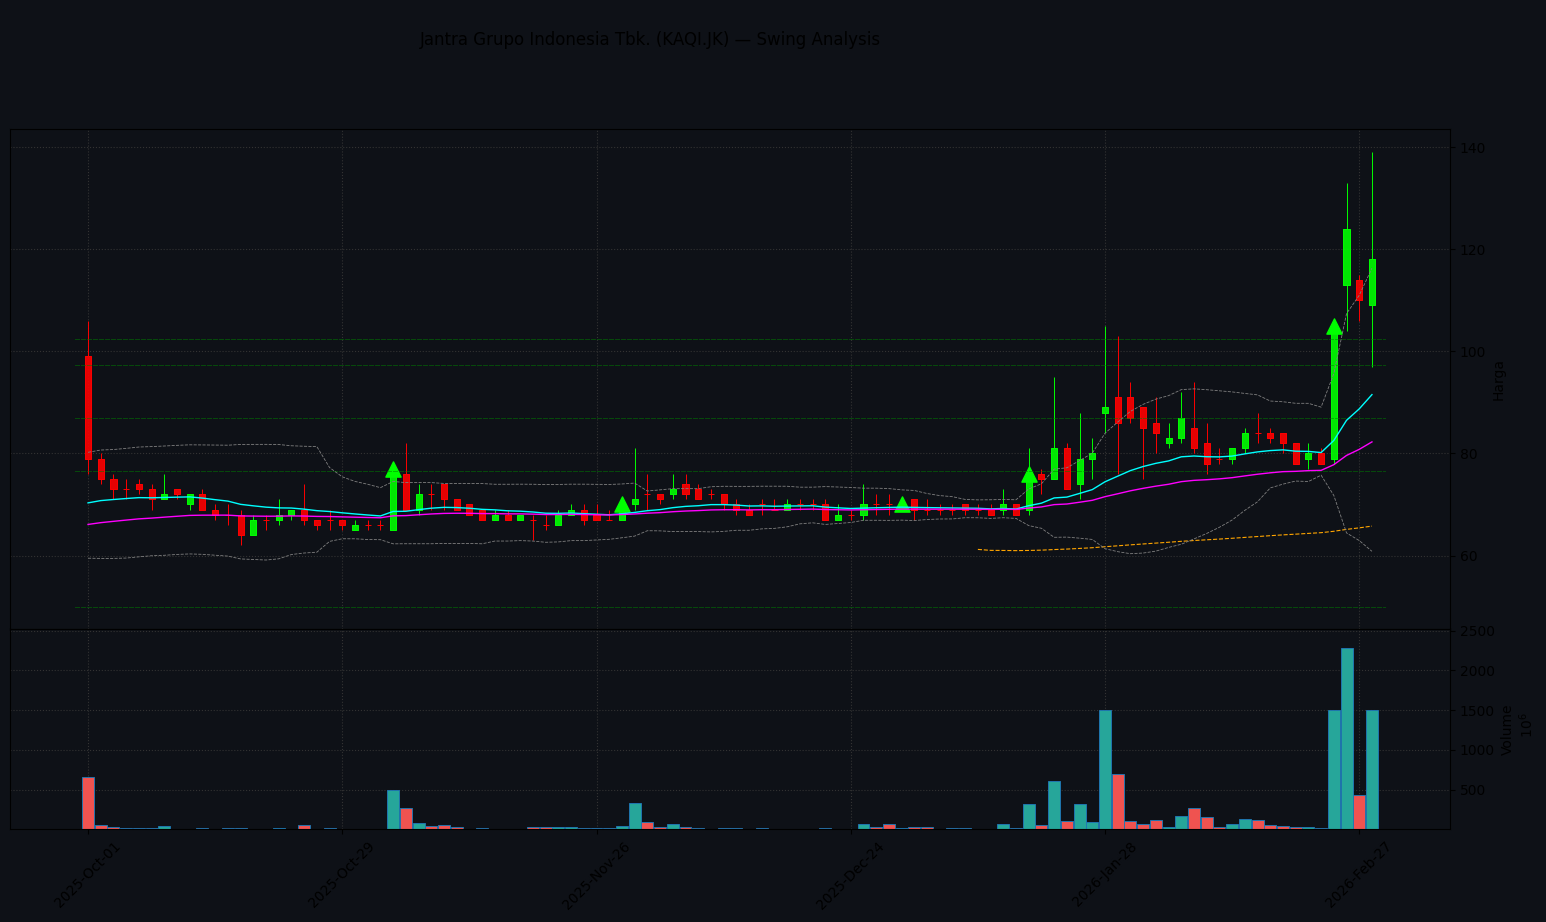

🟢 EMA 20 (cyan) | 🟣 EMA 50 (magenta) | 🟠 SMA 200 (orange dashed) | ⬜ BB 20 (gray)
🔺 Buy (▲ hijau) | 🔻 Sell (▼ merah) | --- Support (hijau) / Resistance (merah)


In [6]:
# ============================================================
# 5) CHART UTAMA — Candlestick + MA + Sinyal + Volume
# ============================================================

# Potong data 6 bulan terakhir agar chart tidak terlalu padat
chart_df = df.last('6M').copy()

# Addplots
ap = []
ap.append(mpf.make_addplot(chart_df['EMA_fast'],  color='cyan',    width=1.0))
ap.append(mpf.make_addplot(chart_df['EMA_slow'],  color='magenta', width=1.0))
if chart_df['SMA_long'].notna().any():
    ap.append(mpf.make_addplot(chart_df['SMA_long'], color='orange', width=0.8, linestyle='--'))

# Bollinger Bands
ap.append(mpf.make_addplot(chart_df['BB_Upper'], color='gray', width=0.6, linestyle='--'))
ap.append(mpf.make_addplot(chart_df['BB_Lower'], color='gray', width=0.6, linestyle='--'))

# Buy / Sell markers
buy_marker  = chart_df['Close'].where(chart_df['Buy_Signal'],  np.nan)
sell_marker  = chart_df['Close'].where(chart_df['Sell_Signal'], np.nan)
if buy_marker.notna().any():
    ap.append(mpf.make_addplot(buy_marker,  type='scatter', markersize=120, marker='^', color='lime'))
if sell_marker.notna().any():
    ap.append(mpf.make_addplot(sell_marker, type='scatter', markersize=120, marker='v', color='red'))

# Support / Resistance lines via hlines
sr_lines = dict(hlines=support_levels + resistance_levels,
                colors=['green']*len(support_levels) + ['red']*len(resistance_levels),
                linewidths=0.8, linestyle='--', alpha=0.5)

# Style
mc = mpf.make_marketcolors(up='lime', down='red', edge='inherit',
                            wick={'up': 'lime', 'down': 'red'},
                            volume={'up': '#26a69a', 'down': '#ef5350'})
style = mpf.make_mpf_style(marketcolors=mc, gridstyle=':', gridcolor='#333',
                            facecolor='#0e1117', figcolor='#0e1117',
                            y_on_right=True)

fig, axes = mpf.plot(chart_df, type='candle', style=style,
                      addplot=ap, volume=True,
                      hlines=sr_lines,
                      figsize=(20, 10), returnfig=True,
                      title=f'\n{company_name} ({TICKER}) — Swing Analysis',
                      ylabel='Harga', ylabel_lower='Volume')

plt.savefig(f'{FIG_DIR}/01_main_chart.png', bbox_inches='tight', facecolor='#0e1117')
plt.show()
print(f"🟢 EMA {EMA_FAST} (cyan) | 🟣 EMA {EMA_SLOW} (magenta) | 🟠 SMA {SMA_LONG} (orange dashed)"
      f" | ⬜ BB {BB_PERIOD} (gray)")
print(f"🔺 Buy (▲ hijau) | 🔻 Sell (▼ merah) | --- Support (hijau) / Resistance (merah)")

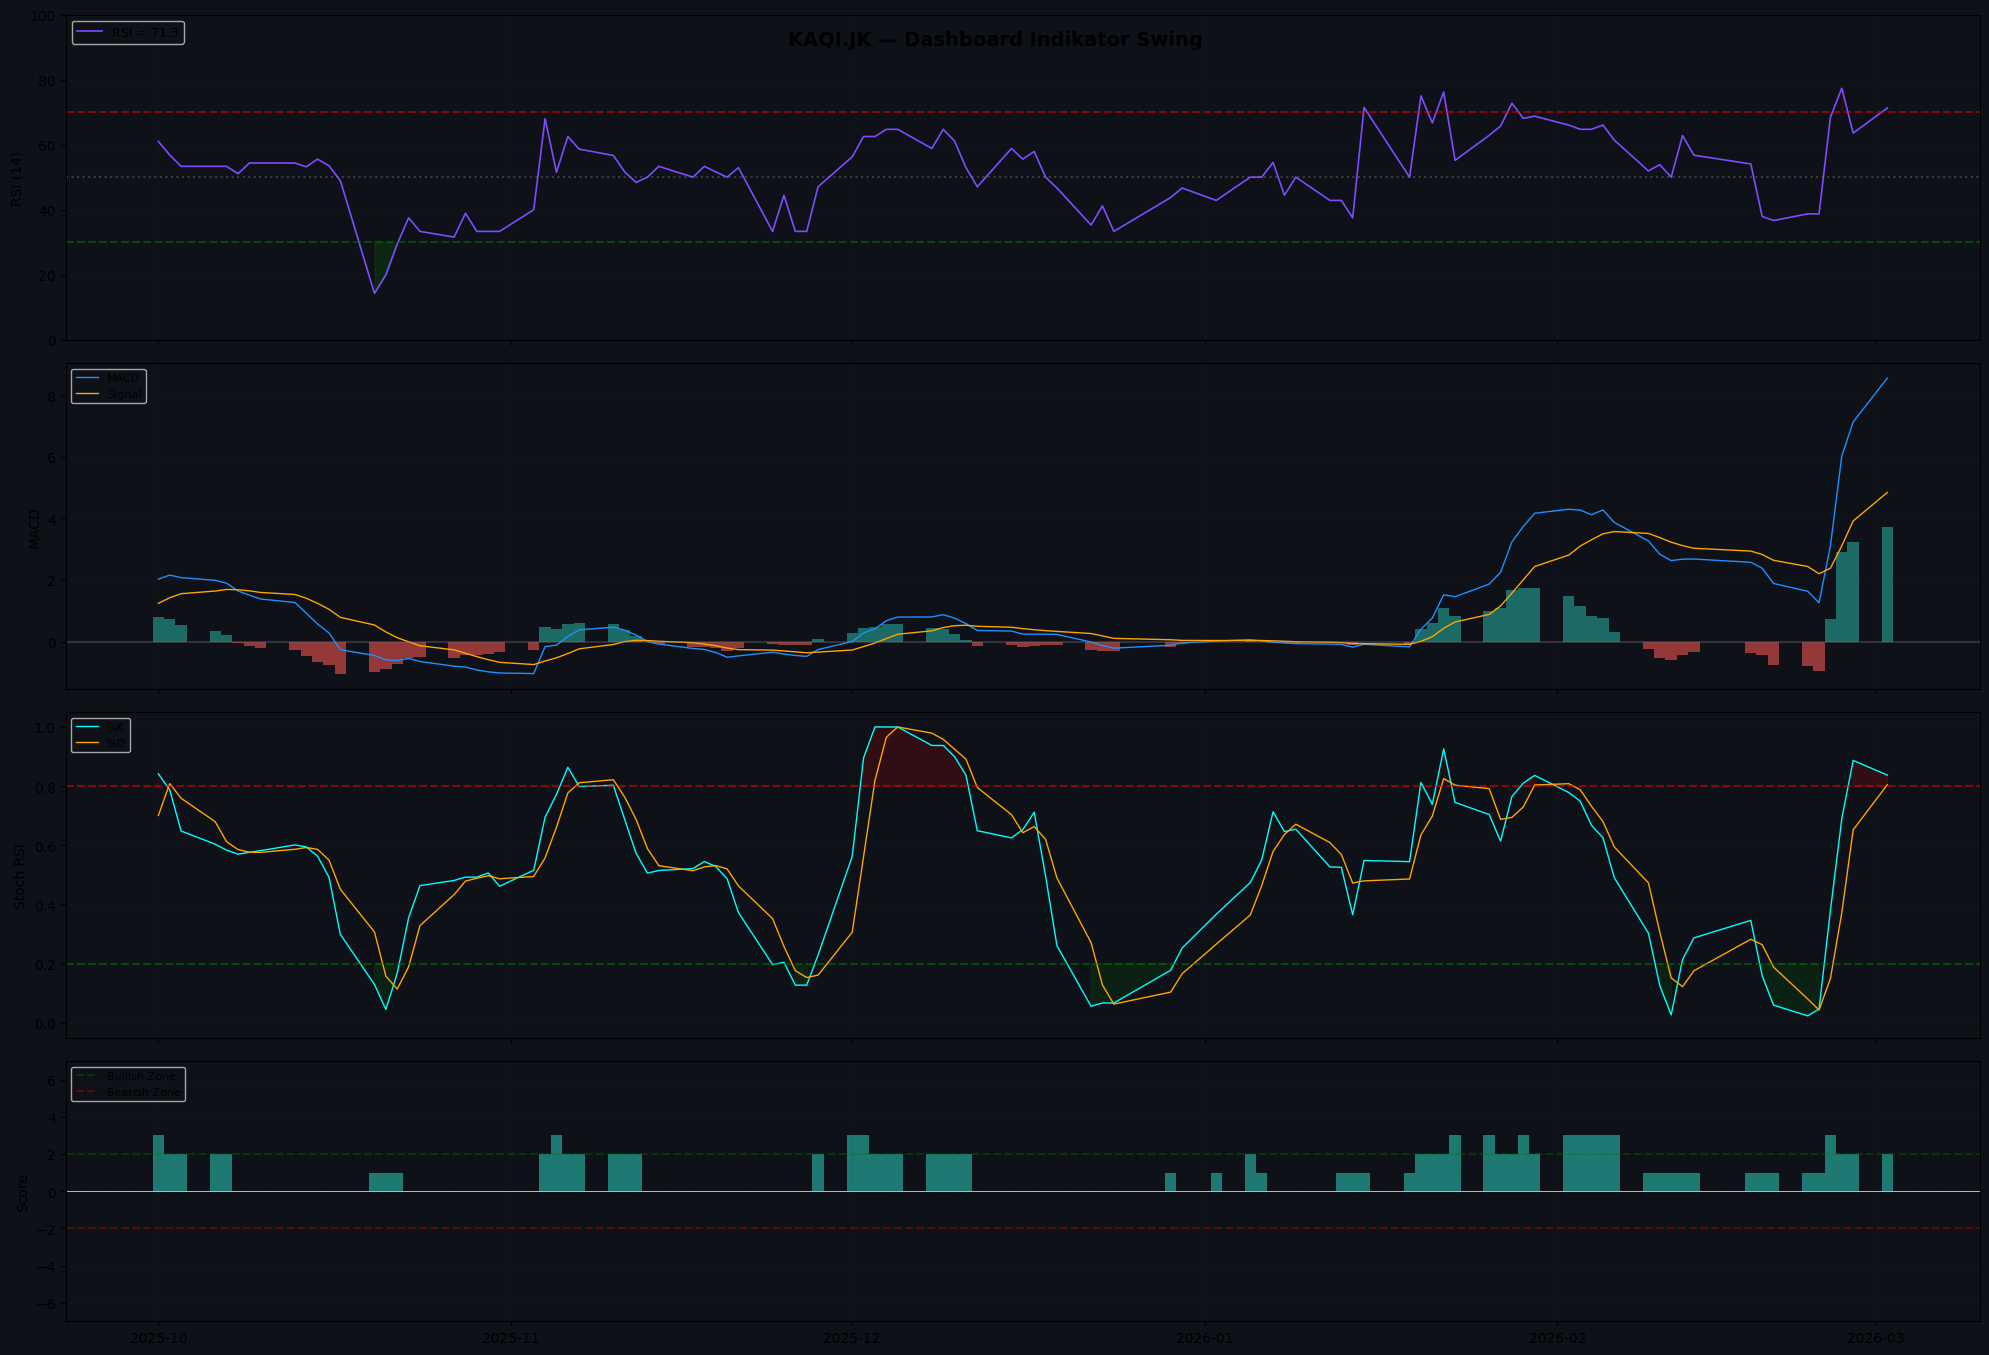

In [7]:
# ============================================================
# 6) DASHBOARD INDIKATOR — RSI, MACD, Stochastic RSI, Score
# ============================================================

fig, axes = plt.subplots(4, 1, figsize=(20, 14), sharex=True,
                          gridspec_kw={'height_ratios': [1, 1, 1, 0.8]})
fig.suptitle(f'{TICKER} — Dashboard Indikator Swing', fontsize=14, fontweight='bold', y=0.95)
x = chart_df.index

# --- RSI ---
ax = axes[0]
ax.plot(x, chart_df['RSI'], color='#7c4dff', linewidth=1.2)
ax.axhline(RSI_OB, color='red',   linestyle='--', alpha=0.5)
ax.axhline(RSI_OS, color='green', linestyle='--', alpha=0.5)
ax.axhline(50,     color='gray',  linestyle=':',  alpha=0.4)
ax.fill_between(x, chart_df['RSI'], RSI_OB, where=chart_df['RSI'] > RSI_OB, color='red',   alpha=0.2)
ax.fill_between(x, chart_df['RSI'], RSI_OS, where=chart_df['RSI'] < RSI_OS, color='green', alpha=0.2)
ax.set_ylabel(f'RSI ({RSI_PERIOD})')
ax.set_ylim(0, 100)
ax.legend([f'RSI = {chart_df["RSI"].iloc[-1]:.1f}'], loc='upper left', fontsize=9)
ax.grid(True, alpha=0.2)

# --- MACD ---
ax = axes[1]
colors_hist = ['#26a69a' if v >= 0 else '#ef5350' for v in chart_df['MACD_Hist']]
ax.bar(x, chart_df['MACD_Hist'], color=colors_hist, alpha=0.6, width=1)
ax.plot(x, chart_df['MACD'],        color='dodgerblue', linewidth=1, label='MACD')
ax.plot(x, chart_df['MACD_Signal'], color='orange',     linewidth=1, label='Signal')
ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax.set_ylabel('MACD')
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.2)

# --- Stochastic RSI ---
ax = axes[2]
ax.plot(x, chart_df['StochRSI_K'], color='cyan',   linewidth=1, label='%K')
ax.plot(x, chart_df['StochRSI_D'], color='orange',  linewidth=1, label='%D')
ax.axhline(0.8, color='red',   linestyle='--', alpha=0.5)
ax.axhline(0.2, color='green', linestyle='--', alpha=0.5)
ax.fill_between(x, chart_df['StochRSI_K'], 0.8,
                where=chart_df['StochRSI_K'] > 0.8, color='red', alpha=0.15)
ax.fill_between(x, chart_df['StochRSI_K'], 0.2,
                where=chart_df['StochRSI_K'] < 0.2, color='green', alpha=0.15)
ax.set_ylabel('Stoch RSI')
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.2)

# --- Composite Score ---
ax = axes[3]
score_colors = ['#26a69a' if v > 0 else '#ef5350' if v < 0 else 'gray' for v in chart_df['Score']]
ax.bar(x, chart_df['Score'], color=score_colors, alpha=0.7, width=1)
ax.axhline(0, color='white', linewidth=0.5)
ax.axhline(2,  color='green', linestyle='--', alpha=0.3, label='Bullish Zone')
ax.axhline(-2, color='red',   linestyle='--', alpha=0.3, label='Bearish Zone')
ax.set_ylabel('Score')
ax.set_ylim(-7, 7)
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_indicators.png', bbox_inches='tight')
plt.show()

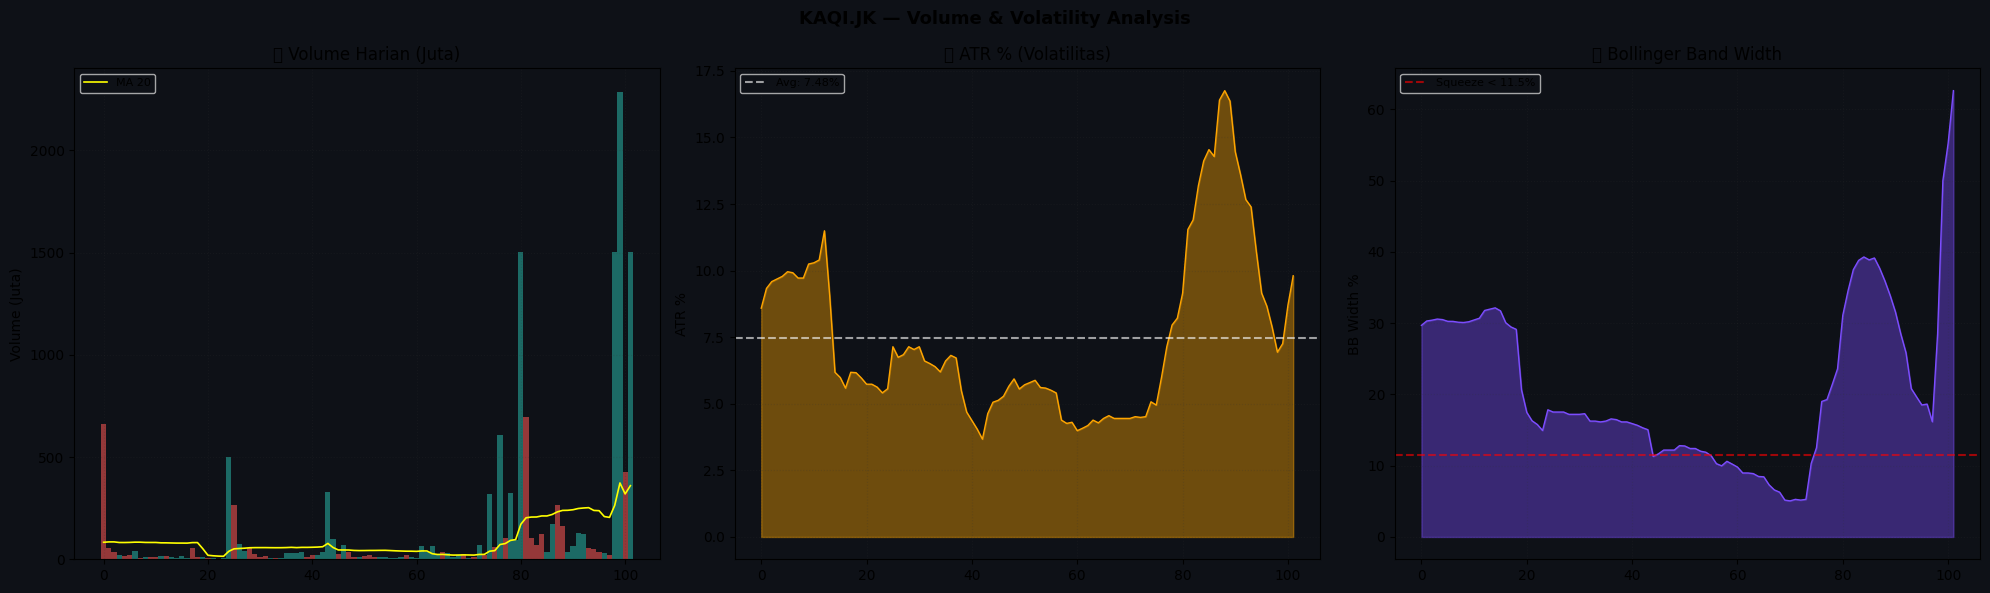

In [8]:
# ============================================================
# 7) VOLUME PROFILE & VOLATILITY
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(f'{TICKER} — Volume & Volatility Analysis', fontsize=13, fontweight='bold')

# --- Volume vs MA ---
ax = axes[0]
vol_colors = ['#26a69a' if c >= o else '#ef5350'
              for c, o in zip(chart_df['Close'], chart_df['Open'])]
ax.bar(range(len(chart_df)), chart_df['Volume'] / 1e6, color=vol_colors, alpha=0.6, width=1)
ax.plot(range(len(chart_df)), chart_df['Vol_MA'] / 1e6, color='yellow', linewidth=1.2, label=f'MA {VOL_MA}')
ax.set_title('📊 Volume Harian (Juta)')
ax.set_ylabel('Volume (Juta)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

# --- ATR (Volatilitas) ---
ax = axes[1]
ax.fill_between(range(len(chart_df)), chart_df['ATR_Pct'], alpha=0.4, color='orange')
ax.plot(range(len(chart_df)), chart_df['ATR_Pct'], color='orange', linewidth=1)
avg_atr = chart_df['ATR_Pct'].mean()
ax.axhline(avg_atr, color='white', linestyle='--', alpha=0.6, label=f'Avg: {avg_atr:.2f}%')
ax.set_title('📈 ATR % (Volatilitas)')
ax.set_ylabel('ATR %')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

# --- Bollinger Band Width ---
ax = axes[2]
ax.fill_between(range(len(chart_df)), chart_df['BB_Width'], alpha=0.4, color='#7c4dff')
ax.plot(range(len(chart_df)), chart_df['BB_Width'], color='#7c4dff', linewidth=1)
squeeze_threshold = chart_df['BB_Width'].quantile(0.2)
ax.axhline(squeeze_threshold, color='red', linestyle='--', alpha=0.6, label=f'Squeeze < {squeeze_threshold:.1f}%')
ax.set_title('📏 Bollinger Band Width')
ax.set_ylabel('BB Width %')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/03_volume_volatility.png', bbox_inches='tight')
plt.show()

In [9]:
# ============================================================
# 8) BACKTEST SEDERHANA (EMA Cross + Score Filter)
# ============================================================

def backtest_swing(data, initial_capital=100_000_000,
                   fee_buy=0.0015, fee_sell=0.0025):
    """
    Backtest swing: Buy saat Buy_Signal, Sell saat Sell_Signal.
    Realistic fee IDX: 0.15% buy + 0.25% sell.
    """
    capital = initial_capital
    position = 0
    in_position = False
    entry_price = 0
    trades = []
    equity = []

    for i in range(len(data)):
        row = data.iloc[i]
        close = float(row['Close'])
        dt = data.index[i]

        # Equity tracking
        eq = capital + (position * close if in_position else 0)
        equity.append({'Date': dt, 'Equity': eq})

        if not in_position and row.get('Buy_Signal', False):
            # --- BUY ---
            buy_price = close
            shares = int((capital * 0.95) / (buy_price * 100)) * 100
            if shares >= 100:
                cost = shares * buy_price
                fee = cost * fee_buy
                capital -= (cost + fee)
                position = shares
                entry_price = buy_price
                in_position = True
                trades.append({'Entry_Date': dt, 'Entry_Price': buy_price,
                               'Shares': shares, 'Fee_Buy': fee})

        elif in_position and row.get('Sell_Signal', False):
            # --- SELL ---
            sell_price = close
            revenue = position * sell_price
            fee = revenue * fee_sell
            pnl = (sell_price - entry_price) * position - trades[-1]['Fee_Buy'] - fee
            capital += (revenue - fee)

            trades[-1].update({
                'Exit_Date': dt, 'Exit_Price': sell_price,
                'Fee_Sell': fee,
                'PnL': pnl,
                'PnL_Pct': (sell_price / entry_price - 1) * 100,
                'Hold_Days': (dt - trades[-1]['Entry_Date']).days
            })
            position = 0
            in_position = False

    # Force close
    if in_position:
        close = float(data['Close'].iloc[-1])
        revenue = position * close
        fee = revenue * fee_sell
        pnl = (close - entry_price) * position - trades[-1]['Fee_Buy'] - fee
        capital += (revenue - fee)
        trades[-1].update({
            'Exit_Date': data.index[-1], 'Exit_Price': close,
            'Fee_Sell': fee, 'PnL': pnl,
            'PnL_Pct': (close / entry_price - 1) * 100,
            'Hold_Days': (data.index[-1] - trades[-1]['Entry_Date']).days
        })

    equity_df = pd.DataFrame(equity).set_index('Date')
    trades_df = pd.DataFrame(trades)
    return capital, equity_df, trades_df

# ===== Run Backtest =====
INITIAL = 100_000_000
final_cap, equity_df, trades_df = backtest_swing(df, INITIAL)
bh_return = (df['Close'].iloc[-1] / df['Close'].iloc[0] - 1) * 100

# ===== Performance Metrics =====
total_return = (final_cap - INITIAL) / INITIAL * 100
closed = trades_df[trades_df['PnL'].notna()] if len(trades_df) > 0 else pd.DataFrame()
n_trades = len(closed)

print(f"{'═' * 60}")
print(f"  📊 BACKTEST RESULT — {TICKER}")
print(f"{'═' * 60}")
print(f"  Modal Awal    : Rp {INITIAL:>18,.0f}")
print(f"  Modal Akhir   : Rp {final_cap:>18,.0f}")
print(f"  Return Strat  : {total_return:>+12.2f}%")
print(f"  Buy & Hold    : {float(bh_return):>+12.2f}%")
print(f"  Alpha         : {total_return - float(bh_return):>+12.2f}%")
print(f"{'─' * 60}")

if n_trades > 0:
    wins   = closed[closed['PnL'] > 0]
    losses = closed[closed['PnL'] <= 0]
    wr = len(wins) / n_trades * 100

    avg_win  = wins['PnL_Pct'].mean() if len(wins) > 0 else 0
    avg_loss = losses['PnL_Pct'].mean() if len(losses) > 0 else 0
    profit_factor = abs(wins['PnL'].sum() / losses['PnL'].sum()) if len(losses) > 0 and losses['PnL'].sum() != 0 else float('inf')
    expectancy = closed['PnL'].mean()
    total_fees = closed['Fee_Buy'].sum() + closed['Fee_Sell'].sum()
    avg_hold = closed['Hold_Days'].mean()

    # Max drawdown
    peak = equity_df['Equity'].cummax()
    dd = (equity_df['Equity'] - peak) / peak * 100
    max_dd = dd.min()

    print(f"  Total Trades  : {n_trades}")
    print(f"  Win / Loss    : {len(wins)} / {len(losses)}")
    print(f"  Win Rate      : {wr:.1f}%")
    print(f"  Avg Win       : {avg_win:+.2f}%")
    print(f"  Avg Loss      : {avg_loss:+.2f}%")
    print(f"  Profit Factor : {profit_factor:.2f}")
    print(f"  Expectancy    : Rp {expectancy:+,.0f} / trade")
    print(f"  Max Drawdown  : {max_dd:.2f}%")
    print(f"  Avg Hold Days : {avg_hold:.0f} hari")
    print(f"  Total Fees    : Rp {total_fees:,.0f}")
else:
    print("  ⚠️ Tidak ada trade signal dalam periode ini.")
print(f"{'═' * 60}")

════════════════════════════════════════════════════════════
  📊 BACKTEST RESULT — KAQI.JK
════════════════════════════════════════════════════════════
  Modal Awal    : Rp        100,000,000
  Modal Akhir   : Rp        150,075,266
  Return Strat  :       +50.08%
  Buy & Hold    :       +11.32%
  Alpha         :       +38.75%
────────────────────────────────────────────────────────────
  Total Trades  : 1
  Win / Loss    : 1 / 0
  Win Rate      : 100.0%
  Avg Win       : +53.25%
  Avg Loss      : +0.00%
  Profit Factor : inf
  Expectancy    : Rp +50,075,266 / trade
  Max Drawdown  : -13.71%
  Avg Hold Days : 118 hari
  Total Fees    : Rp 506,434
════════════════════════════════════════════════════════════


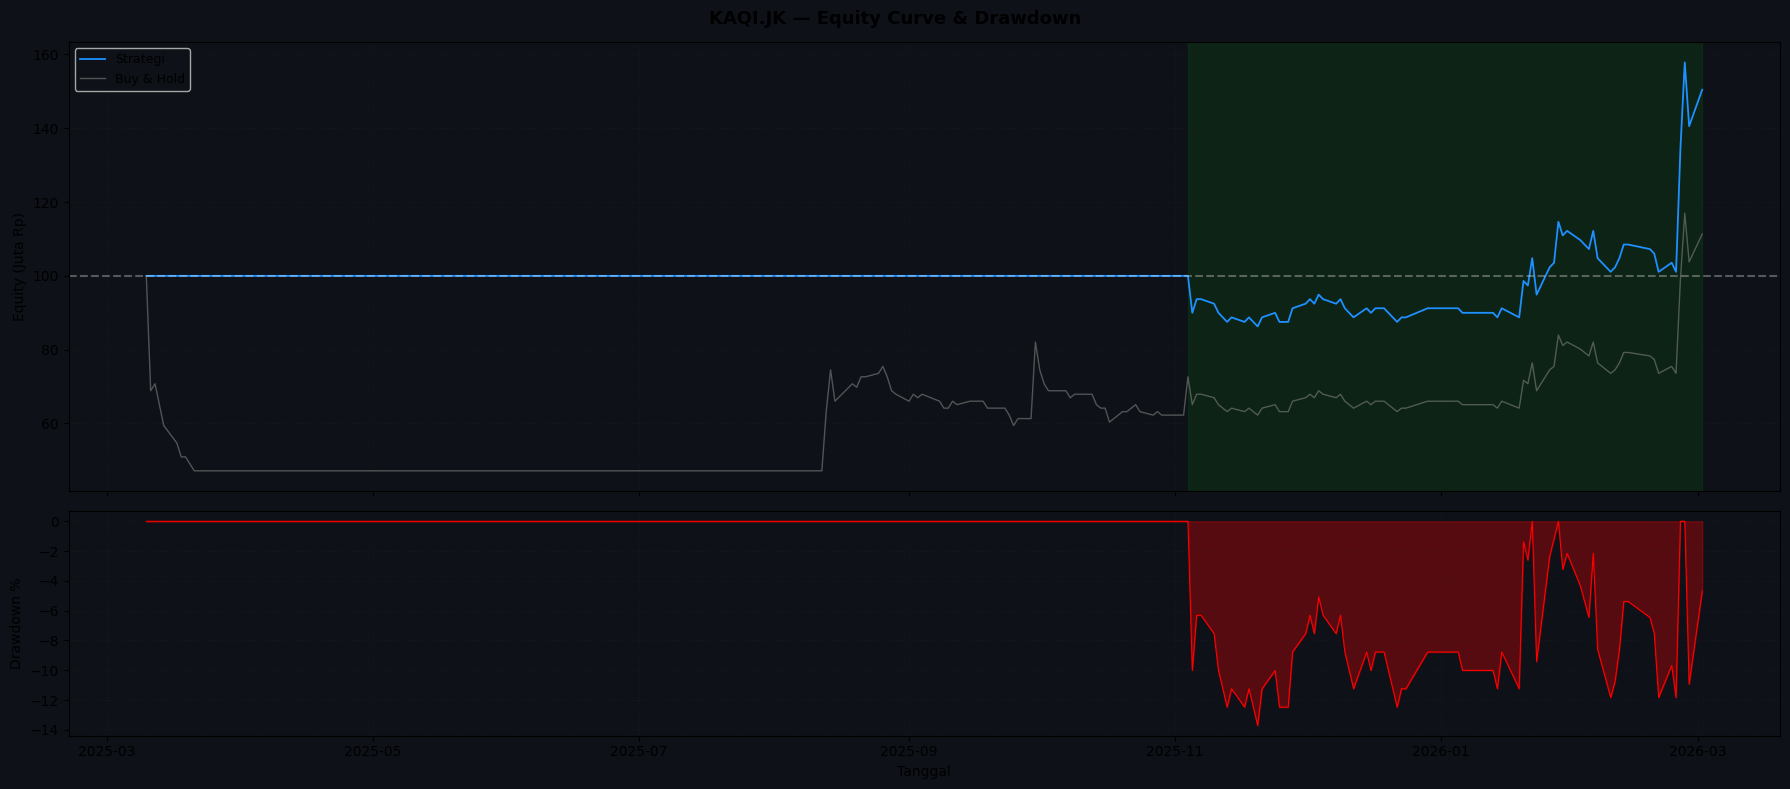

In [10]:
# ============================================================
# 9) VISUALISASI EQUITY & DRAWDOWN
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True,
                          gridspec_kw={'height_ratios': [2, 1]})
fig.suptitle(f'{TICKER} — Equity Curve & Drawdown', fontsize=13, fontweight='bold')

# --- Equity ---
ax = axes[0]
ax.plot(equity_df.index, equity_df['Equity'] / 1e6, color='dodgerblue', linewidth=1.3, label='Strategi')
# Buy & Hold equity
bh_equity = INITIAL * (df['Close'] / df['Close'].iloc[0])
ax.plot(df.index, bh_equity / 1e6, color='gray', linewidth=1, alpha=0.6, label='Buy & Hold')
ax.axhline(INITIAL / 1e6, color='white', linestyle='--', alpha=0.3)
ax.set_ylabel('Equity (Juta Rp)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

# Mark trades
if len(closed) > 0:
    for _, t in closed.iterrows():
        color = 'lime' if t['PnL'] > 0 else 'red'
        ax.axvspan(t['Entry_Date'], t['Exit_Date'], alpha=0.08, color=color)

# --- Drawdown ---
ax = axes[1]
peak = equity_df['Equity'].cummax()
dd = (equity_df['Equity'] - peak) / peak * 100
ax.fill_between(equity_df.index, dd, 0, color='red', alpha=0.3)
ax.plot(equity_df.index, dd, color='red', linewidth=0.8)
ax.set_ylabel('Drawdown %')
ax.set_xlabel('Tanggal')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/04_equity_drawdown.png', bbox_inches='tight')
plt.show()

📋 TRADE LOG — KAQI.JK (1 trades)
────────────────────────────────────────────────────────────────────────────────────────────────────
  # 1 │ 2025-11-04 → 2026-03-02 │ Entry:         77 → Exit:        118 │ 118d │ +53.25% │ Rp    +50,075,266 │ ✅ WIN
────────────────────────────────────────────────────────────────────────────────────────────────────


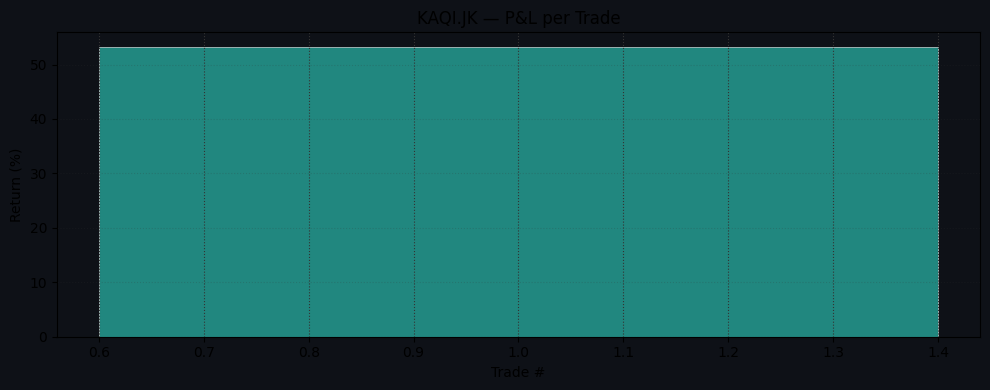

In [11]:
# ============================================================
# 10) TRADE LOG — Detail Setiap Transaksi
# ============================================================

if len(closed) > 0:
    display_cols = ['Entry_Date', 'Entry_Price', 'Exit_Date', 'Exit_Price',
                    'Shares', 'Hold_Days', 'PnL_Pct', 'PnL']
    
    trade_log = closed[display_cols].copy()
    trade_log['Entry_Date'] = trade_log['Entry_Date'].dt.strftime('%Y-%m-%d')
    trade_log['Exit_Date']  = trade_log['Exit_Date'].dt.strftime('%Y-%m-%d')
    trade_log['Result'] = trade_log['PnL'].apply(lambda x: '✅ WIN' if x > 0 else '❌ LOSS')
    
    print(f"📋 TRADE LOG — {TICKER} ({len(closed)} trades)")
    print("─" * 100)
    for i, (_, t) in enumerate(trade_log.iterrows(), 1):
        print(f"  #{i:2d} │ {t['Entry_Date']} → {t['Exit_Date']} │ "
              f"Entry: {t['Entry_Price']:>10,.0f} → Exit: {t['Exit_Price']:>10,.0f} │ "
              f"{t['Hold_Days']:3.0f}d │ {t['PnL_Pct']:+6.2f}% │ "
              f"Rp {t['PnL']:>+14,.0f} │ {t['Result']}")
    print("─" * 100)
    
    # PnL Distribution chart
    fig, ax = plt.subplots(figsize=(10, 4))
    colors = ['#26a69a' if x > 0 else '#ef5350' for x in closed['PnL_Pct']]
    ax.bar(range(1, n_trades+1), closed['PnL_Pct'].values, color=colors, alpha=0.8, edgecolor='white', linewidth=0.5)
    ax.axhline(0, color='white', linewidth=0.5)
    ax.set_xlabel('Trade #')
    ax.set_ylabel('Return (%)')
    ax.set_title(f'{TICKER} — P&L per Trade')
    ax.grid(True, alpha=0.2, axis='y')
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/05_pnl_per_trade.png', bbox_inches='tight')
    plt.show()
else:
    print("⚠️ Tidak ada trade untuk ditampilkan.")

📥 Download IHSG (^JKSE) untuk analisis korelasi...
   ✅ IHSG: 236 hari

═════════════════════════════════════════════════════════════════
  📊 KORELASI KAQI.JK vs IHSG
═════════════════════════════════════════════════════════════════
  Korelasi Harian  : +0.0150  🟢 LEMAH
  Korelasi 5-Hari  : +0.1328
  Beta (β)         : 0.0608  🛡️Defensif
  R-Squared        : 0.0002 (0.0% dipengaruhi IHSG)

  Kondisi          │  Hari │  Avg Ret │   Win% │   Avg 5d
  ─────────────────┼───────┼──────────┼────────┼─────────
  IHSG Bullish     │   169 │  +0.493% │  20.7% │  +1.896%
  IHSG Netral      │    19 │  -0.813% │  15.8% │  -2.604%
  IHSG Bearish     │    38 │  +0.596% │  23.7% │  +0.727%
  Semua Hari       │   226 │  +0.401% │  20.8% │  +1.321%


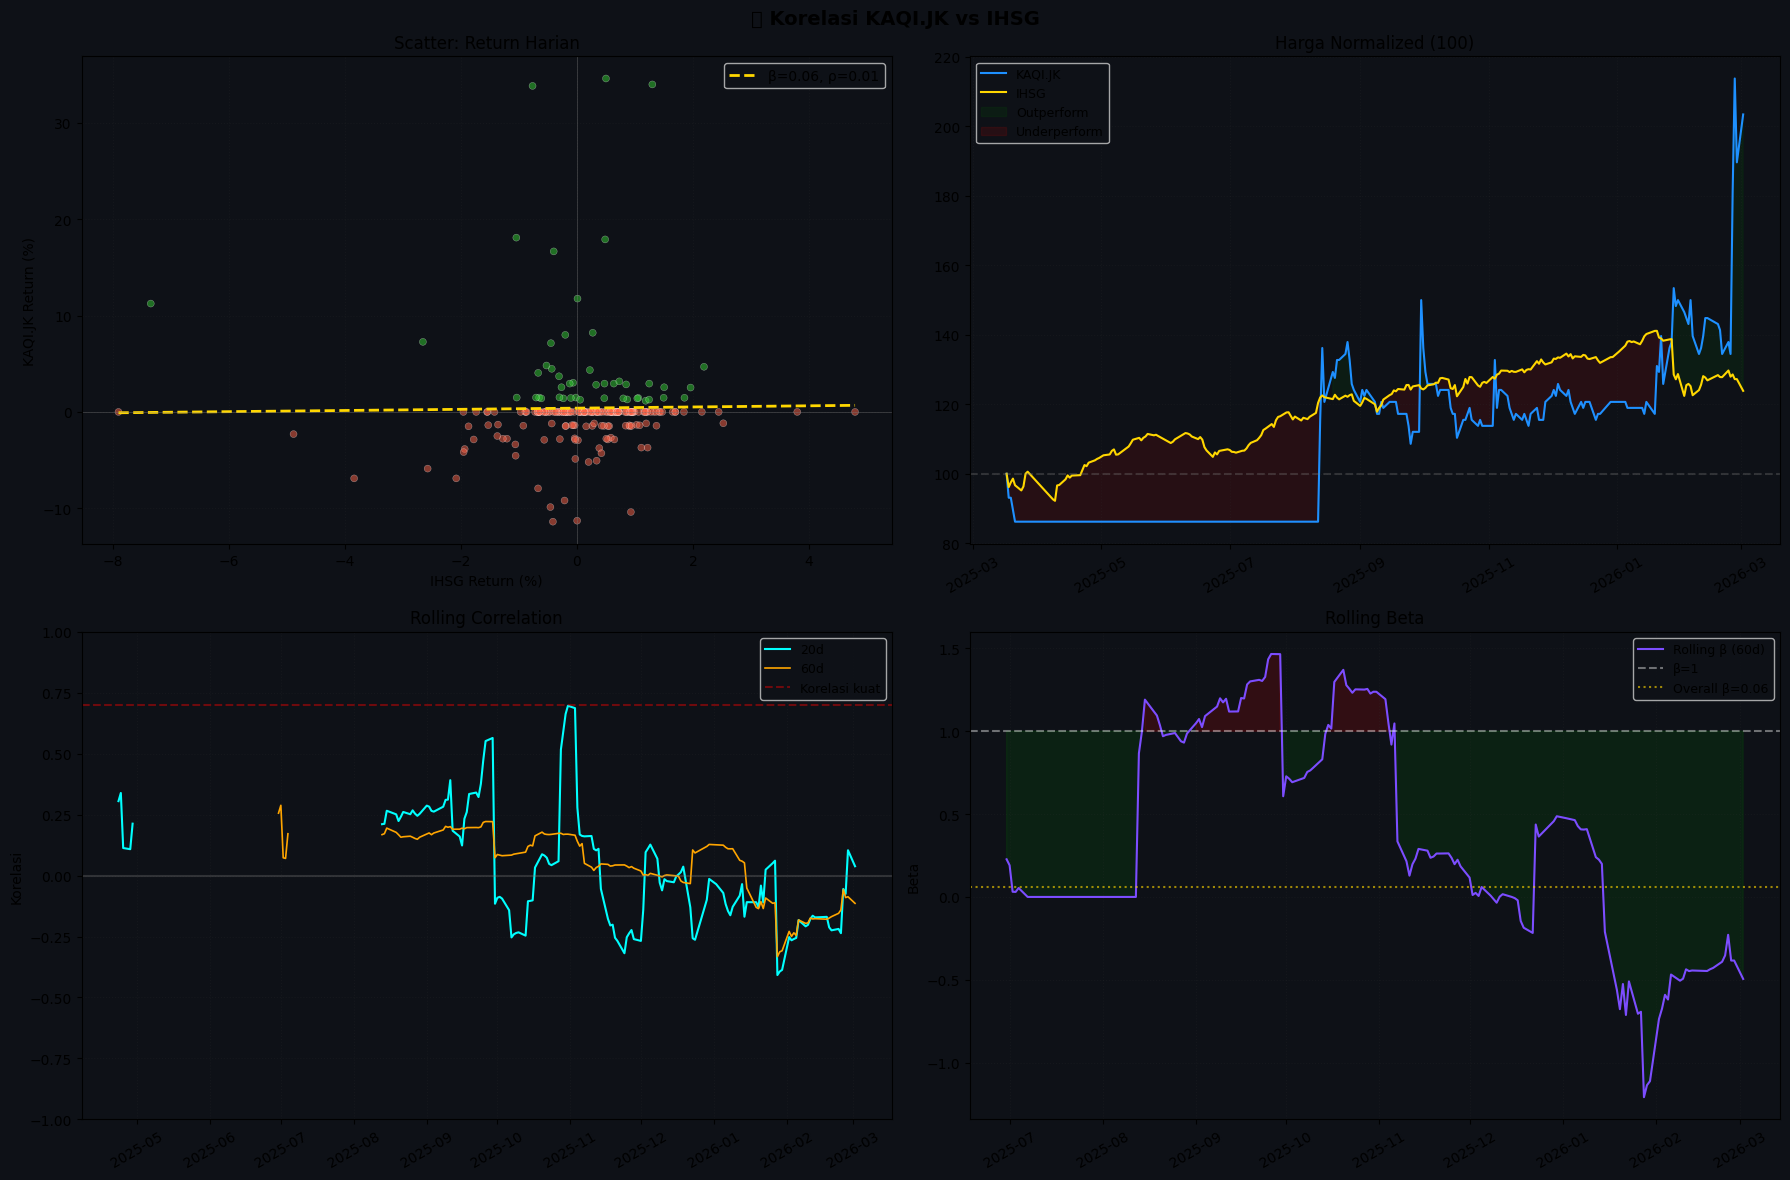


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🏛️ IHSG SAAT INI: Bearish 🔴 | IHSG: 8,016.83 | 5d: -4.52%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🔴 IHSG bearish → hati-hati swing BUY, ketatkan SL


In [12]:
# ============================================================
# 10b) ANALISIS KORELASI DENGAN IHSG
# ============================================================

print(f"📥 Download IHSG (^JKSE) untuk analisis korelasi...")
IHSG_TICKER = "^JKSE"

try:
    ihsg_raw = yf.download(IHSG_TICKER, period=PERIOD, interval=INTERVAL, progress=False)
    if isinstance(ihsg_raw.columns, pd.MultiIndex):
        ihsg_raw.columns = [c[0] if isinstance(c, tuple) else c for c in ihsg_raw.columns]
    ihsg = ihsg_raw[['Close', 'Volume']].dropna().copy()
    ihsg.columns = ['IHSG_Close', 'IHSG_Volume']
    if ihsg.index.tz is not None:
        ihsg.index = ihsg.index.tz_localize(None)
    ihsg_ok = True
    print(f"   ✅ IHSG: {len(ihsg)} hari")
except Exception as e:
    print(f"   ⚠️ Gagal download IHSG: {e}")
    ihsg_ok = False

if ihsg_ok:
    # Merge
    stock_corr = df[['Close', 'Volume']].copy()
    stock_corr.columns = ['Stock_Close', 'Stock_Volume']
    mg = stock_corr.join(ihsg, how='inner').dropna()
    mg['Stock_Ret'] = mg['Stock_Close'].pct_change() * 100
    mg['IHSG_Ret']  = mg['IHSG_Close'].pct_change() * 100
    mg['Stock_Ret5'] = mg['Stock_Close'].pct_change(5) * 100
    mg['IHSG_Ret5']  = mg['IHSG_Close'].pct_change(5) * 100
    mg = mg.dropna()

    # Korelasi & Beta
    corr_d = mg['Stock_Ret'].corr(mg['IHSG_Ret'])
    corr_5d = mg['Stock_Ret5'].corr(mg['IHSG_Ret5'])
    cov_m = np.cov(mg['IHSG_Ret'], mg['Stock_Ret'])
    beta_val = cov_m[0, 1] / cov_m[0, 0]
    r_sq = corr_d ** 2

    # IHSG trend
    mg['IHSG_EMA20'] = mg['IHSG_Close'].ewm(span=20, adjust=False).mean()
    mg['IHSG_EMA50'] = mg['IHSG_Close'].ewm(span=50, adjust=False).mean()
    mg['IHSG_Trend'] = np.where(
        mg['IHSG_Close'] > mg['IHSG_EMA20'], 'Bullish',
        np.where(mg['IHSG_Close'] > mg['IHSG_EMA50'], 'Netral', 'Bearish')
    )

    # Conditional returns
    cond = {
        'IHSG Bullish': mg[mg['IHSG_Trend'] == 'Bullish'],
        'IHSG Netral':  mg[mg['IHSG_Trend'] == 'Netral'],
        'IHSG Bearish': mg[mg['IHSG_Trend'] == 'Bearish'],
        'Semua Hari':   mg,
    }

    print(f"\n{'═' * 65}")
    print(f"  📊 KORELASI {TICKER} vs IHSG")
    print(f"{'═' * 65}")
    print(f"  Korelasi Harian  : {corr_d:+.4f}  {'🔴 KUAT' if abs(corr_d)>0.7 else '🟡 MODERAT' if abs(corr_d)>0.4 else '🟢 LEMAH'}")
    print(f"  Korelasi 5-Hari  : {corr_5d:+.4f}")
    print(f"  Beta (β)         : {beta_val:.4f}  {'⚡Agresif' if beta_val>1.2 else '📊Normal' if beta_val>0.8 else '🛡️Defensif'}")
    print(f"  R-Squared        : {r_sq:.4f} ({r_sq*100:.1f}% dipengaruhi IHSG)")

    print(f"\n  {'Kondisi':<16s} │ {'Hari':>5s} │ {'Avg Ret':>8s} │ {'Win%':>6s} │ {'Avg 5d':>8s}")
    print(f"  {'─'*16}─┼─{'─'*5}─┼─{'─'*8}─┼─{'─'*6}─┼─{'─'*8}")
    for lbl, sub in cond.items():
        if len(sub) > 0:
            avg_r = sub['Stock_Ret'].mean()
            w_pct = (sub['Stock_Ret'] > 0).sum() / len(sub) * 100
            a5 = sub['Stock_Ret5'].mean()
            print(f"  {lbl:<16s} │ {len(sub):>5d} │ {avg_r:>+7.3f}% │ {w_pct:>5.1f}% │ {a5:>+7.3f}%")

    # === VISUALISASI ===
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle(f'📊 Korelasi {TICKER} vs IHSG', fontsize=14, fontweight='bold')

    # 1) Scatter
    ax = axes[0, 0]
    sc_colors = ['limegreen' if r > 0 else 'tomato' for r in mg['Stock_Ret']]
    ax.scatter(mg['IHSG_Ret'], mg['Stock_Ret'], c=sc_colors, alpha=0.5, s=25,
               edgecolors='white', linewidth=0.3)
    z = np.polyfit(mg['IHSG_Ret'], mg['Stock_Ret'], 1)
    xl = np.linspace(mg['IHSG_Ret'].min(), mg['IHSG_Ret'].max(), 100)
    ax.plot(xl, np.poly1d(z)(xl), color='gold', linewidth=2, linestyle='--',
            label=f'β={beta_val:.2f}, ρ={corr_d:.2f}')
    ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
    ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)
    ax.set_xlabel('IHSG Return (%)')
    ax.set_ylabel(f'{TICKER} Return (%)')
    ax.set_title('Scatter: Return Harian')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.2)

    # 2) Normalized overlay
    ax = axes[0, 1]
    ns = mg['Stock_Close'] / mg['Stock_Close'].iloc[0] * 100
    ni = mg['IHSG_Close'] / mg['IHSG_Close'].iloc[0] * 100
    ax.plot(mg.index, ns, color='dodgerblue', linewidth=1.5, label=TICKER)
    ax.plot(mg.index, ni, color='gold', linewidth=1.5, label='IHSG')
    ax.axhline(100, color='gray', linestyle='--', alpha=0.3)
    ax.fill_between(mg.index, ns, ni, where=ns > ni, alpha=0.1, color='green', label='Outperform')
    ax.fill_between(mg.index, ns, ni, where=ns < ni, alpha=0.1, color='red', label='Underperform')
    ax.set_title('Harga Normalized (100)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)
    ax.tick_params(axis='x', rotation=30)

    # 3) Rolling correlation
    ax = axes[1, 0]
    for w, c, lw in [(20, 'cyan', 1.5), (60, 'orange', 1.2)]:
        rc = mg['Stock_Ret'].rolling(w).corr(mg['IHSG_Ret'])
        ax.plot(mg.index, rc, color=c, linewidth=lw, label=f'{w}d')
    ax.axhline(0.7, color='red', linestyle='--', alpha=0.4, label='Korelasi kuat')
    ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
    ax.set_title('Rolling Correlation')
    ax.set_ylabel('Korelasi')
    ax.set_ylim(-1, 1)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)
    ax.tick_params(axis='x', rotation=30)

    # 4) Rolling Beta
    ax = axes[1, 1]
    rw = 60
    rcov = mg['Stock_Ret'].rolling(rw).cov(mg['IHSG_Ret'])
    rvar = mg['IHSG_Ret'].rolling(rw).var()
    rbeta = rcov / rvar
    ax.plot(mg.index, rbeta, color='#7c4dff', linewidth=1.5, label=f'Rolling β ({rw}d)')
    ax.axhline(1, color='white', linestyle='--', alpha=0.4, label='β=1')
    ax.axhline(beta_val, color='gold', linestyle=':', alpha=0.6, label=f'Overall β={beta_val:.2f}')
    ax.fill_between(mg.index, rbeta, 1, where=rbeta > 1, alpha=0.15, color='red')
    ax.fill_between(mg.index, rbeta, 1, where=rbeta < 1, alpha=0.15, color='green')
    ax.set_title('Rolling Beta')
    ax.set_ylabel('Beta')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)
    ax.tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/06_ihsg_correlation.png', bbox_inches='tight')
    plt.show()

    # IHSG Status
    curr_trend = mg['IHSG_Trend'].iloc[-1]
    ihsg_5d = float(mg['IHSG_Ret5'].iloc[-1])
    print(f"\n{'━' * 65}")
    print(f"  🏛️ IHSG SAAT INI: {curr_trend} {'🟢' if curr_trend=='Bullish' else '🟡' if curr_trend=='Netral' else '🔴'}"
          f" | IHSG: {mg['IHSG_Close'].iloc[-1]:,.2f} | 5d: {ihsg_5d:+.2f}%")
    print(f"{'━' * 65}")

    if curr_trend == 'Bullish':
        print(f"  🟢 IHSG mendukung swing BUY {TICKER}")
    elif curr_trend == 'Netral':
        print(f"  🟡 IHSG netral → selektif, kurangi size posisi")
    else:
        print(f"  🔴 IHSG bearish → hati-hati swing BUY, ketatkan SL")

else:
    print("⚠️ Analisis IHSG dilewati (data tidak tersedia).")

📊 Mengambil data fundamental KAQI.JK...

══════════════════════════════════════════════════════════════════════
  🏢 Jantra Grupo Indonesia Tbk. (KAQI.JK)
══════════════════════════════════════════════════════════════════════
  Sektor          : Consumer Cyclical
  Industri        : Auto Parts
  Mata Uang       : IDR
  Website         : https://www.jantragrupoindonesia.com
  Karyawan        : 306

  📝 PT Jantra Grupo Indonesia Tbk engages in repair and maintenance services in Indonesia. It is also involved in trading of vehicle, spare parts and accessories. The company was founded in 2017 and is headquartered in South Tangerang, Indonesia. PT Jantra Grupo Indonesia Tbk is a subsidiary of PT Tahta...

══════════════════════════════════════════════════════════════════════
  💰 RASIO VALUASI
══════════════════════════════════════════════════════════════════════
  Market Cap      : IDR      244,944,404,480
  P/E TTM         : N/A (perusahaan mungkin rugi)
  P/B Ratio       :       2.09  🟡 Wa

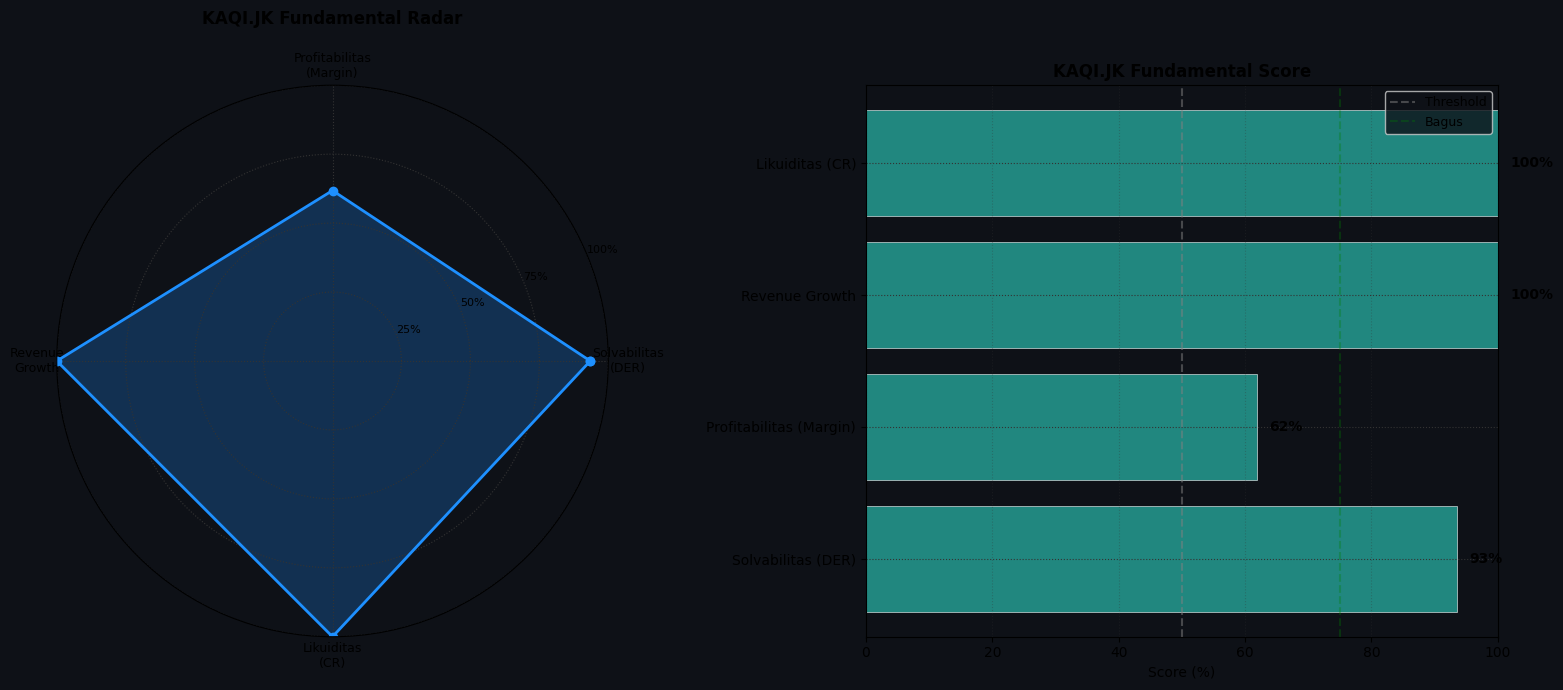

In [13]:
# ============================================================
# 10c) 📊 ANALISIS FUNDAMENTAL SAHAM
# ============================================================

import yfinance as yf

print(f"📊 Mengambil data fundamental {TICKER}...")
fund_stock = yf.Ticker(TICKER)
info = fund_stock.info

# ── Deteksi & koreksi currency mismatch (umum untuk saham .JK) ──
# yfinance sering melaporkan harga IDR tapi keuangan USD → rasio jadi salah
trade_ccy = info.get('currency', 'IDR')
fin_ccy   = info.get('financialCurrency', trade_ccy)
fx_rate   = 1.0

if trade_ccy != fin_ccy:
    try:
        fx_pair = f"{fin_ccy}{trade_ccy}=X"  # e.g. USDIDR=X
        fx_data = yf.download(fx_pair, period='5d', progress=False)
        if isinstance(fx_data.columns, pd.MultiIndex):
            fx_data.columns = [c[0] if isinstance(c, tuple) else c for c in fx_data.columns]
        if len(fx_data) > 0:
            fx_rate = float(fx_data['Close'].iloc[-1])
            print(f"   ⚠️ Currency mismatch terdeteksi: harga dalam {trade_ccy}, laporan keuangan dalam {fin_ccy}")
            print(f"   💱 Kurs: 1 {fin_ccy} = {fx_rate:,.0f} {trade_ccy} → rasio akan dikoreksi otomatis")
    except Exception as e:
        print(f"   ⚠️ Gagal ambil kurs {fin_ccy}/{trade_ccy}: {e}")
        fx_rate = 1.0

def fix_ratio(val, threshold=100):
    """Koreksi rasio yang terinflasi akibat currency mismatch."""
    if val is None or fx_rate <= 1:
        return val
    if abs(val) > threshold:
        return val / fx_rate
    return val

# ══════════════════════════════════════════════════════════════
# A) INFO UMUM PERUSAHAAN
# ══════════════════════════════════════════════════════════════
company_name = info.get('longName', info.get('shortName', TICKER))
f_name       = company_name
f_sector     = info.get('sector', '-')
f_industry   = info.get('industry', '-')
f_currency   = info.get('currency', 'IDR')
f_market_cap = info.get('marketCap', 0)
f_employees  = info.get('fullTimeEmployees', 0)
f_website    = info.get('website', '-')
f_summary    = info.get('longBusinessSummary', '-')

print(f"\n{'═' * 70}")
print(f"  🏢 {company_name} ({TICKER})")
print(f"{'═' * 70}")
print(f"  Sektor          : {f_sector}")
print(f"  Industri        : {f_industry}")
print(f"  Mata Uang       : {f_currency}")
print(f"  Website         : {f_website}")
if f_employees:
    print(f"  Karyawan        : {f_employees:,}")
if f_summary and f_summary != '-':
    print(f"\n  📝 {f_summary[:300]}{'...' if len(f_summary) > 300 else ''}")

# ══════════════════════════════════════════════════════════════
# B) RASIO VALUASI
# ══════════════════════════════════════════════════════════════
pe_trailing  = info.get('trailingPE', None)        # TTM — biasanya sudah benar
pe_forward   = fix_ratio(info.get('forwardPE', None), 500)
pb_ratio     = fix_ratio(info.get('priceToBook', None), 100)
ps_ratio     = fix_ratio(info.get('priceToSalesTrailing12Months', None), 100)
peg_ratio    = info.get('pegRatio', None)
ev_ebitda    = fix_ratio(info.get('enterpriseToEbitda', None), 500)

# Koreksi dividendYield yang kadang sudah dalam % (bukan desimal)
_raw_dy = info.get('dividendYield', None)
if _raw_dy and _raw_dy > 1:
    info['dividendYield'] = _raw_dy / 100

print(f"\n{'═' * 70}")
print(f"  💰 RASIO VALUASI")
print(f"{'═' * 70}")
print(f"  Market Cap      : {f_currency} {f_market_cap:>20,.0f}" if f_market_cap else "  Market Cap      : N/A")

if pe_trailing:
    pe_verdict = "🟢 Murah" if pe_trailing < 15 else "🟡 Wajar" if pe_trailing < 25 else "🔴 Mahal"
    print(f"  P/E TTM         : {pe_trailing:>10.2f}  {pe_verdict}")
    print(f"     💡 TTM = 12 bulan terakhir (data aktual, paling andal)")
    print(f"        Investor bayar {pe_trailing:.0f}x lipat laba tahunan.")
else:
    print(f"  P/E TTM         : N/A (perusahaan mungkin rugi)")

if pe_forward:
    pe_f_verdict = "🟢 Murah" if pe_forward < 15 else "🟡 Wajar" if pe_forward < 25 else "🔴 Mahal"
    print(f"  P/E Forward     : {pe_forward:>10.2f}  {pe_f_verdict}")
    print(f"     💡 Forward = estimasi analis untuk tahun depan (bisa meleset)")
    if pe_trailing and pe_forward < pe_trailing:
        print(f"     📈 Forward < TTM → analis ekspektasi laba NAIK")
    elif pe_trailing and pe_forward > pe_trailing:
        print(f"     📉 Forward > TTM → analis ekspektasi laba TURUN")

if pb_ratio:
    pb_verdict = "🟢 Diskon" if pb_ratio < 1 else "🟡 Wajar" if pb_ratio < 3 else "🔴 Premium"
    print(f"  P/B Ratio       : {pb_ratio:>10.2f}  {pb_verdict}")
    print(f"     💡 P/B < 1 = harga di bawah nilai buku (diskon)")

if ps_ratio:
    ps_verdict = "🟢 Murah" if ps_ratio < 2 else "🟡 Wajar" if ps_ratio < 5 else "🔴 Mahal"
    print(f"  P/S Ratio       : {ps_ratio:>10.2f}  {ps_verdict}")

if peg_ratio:
    peg_verdict = "🟢 Undervalued" if peg_ratio < 1 else "🟡 Fair" if peg_ratio < 2 else "🔴 Overvalued"
    print(f"  PEG Ratio       : {peg_ratio:>10.2f}  {peg_verdict}")
    print(f"     💡 PEG = P/E ÷ growth rate. < 1 = murah relatif terhadap pertumbuhan")

if ev_ebitda:
    ev_verdict = "🟢 Murah" if ev_ebitda < 10 else "🟡 Wajar" if ev_ebitda < 15 else "🔴 Mahal"
    print(f"  EV/EBITDA       : {ev_ebitda:>10.2f}  {ev_verdict}")

# ══════════════════════════════════════════════════════════════
# C) RASIO PROFITABILITAS
# ══════════════════════════════════════════════════════════════
roe           = info.get('returnOnEquity', None)
roa           = info.get('returnOnAssets', None)
profit_margin = info.get('profitMargins', None)
op_margin     = info.get('operatingMargins', None)
gross_margin  = info.get('grossMargins', None)

print(f"\n{'═' * 70}")
print(f"  📈 RASIO PROFITABILITAS")
print(f"{'═' * 70}")

if roe:
    roe_pct = roe * 100
    roe_verdict = "🟢 Sangat Bagus" if roe_pct > 20 else "🟢 Bagus" if roe_pct > 15 else "🟡 Cukup" if roe_pct > 10 else "🔴 Rendah"
    print(f"  ROE             : {roe_pct:>10.2f}%  {roe_verdict}")
    print(f"     💡 Seberapa efisien modal pemegang saham menghasilkan laba")

if roa:
    roa_pct = roa * 100
    roa_verdict = "🟢 Bagus" if roa_pct > 10 else "🟡 Cukup" if roa_pct > 5 else "🔴 Rendah"
    print(f"  ROA             : {roa_pct:>10.2f}%  {roa_verdict}")

if profit_margin:
    npm_pct = profit_margin * 100
    npm_verdict = "🟢 Tinggi" if npm_pct > 15 else "🟡 Cukup" if npm_pct > 5 else "🔴 Tipis"
    print(f"  Net Profit Mrgn : {npm_pct:>10.2f}%  {npm_verdict}")
    print(f"     💡 Dari setiap Rp 100 pendapatan → laba bersih = Rp {npm_pct:.0f}")

if op_margin:
    opm_pct = op_margin * 100
    print(f"  Operating Margin: {opm_pct:>10.2f}%")

if gross_margin:
    gm_pct = gross_margin * 100
    print(f"  Gross Margin    : {gm_pct:>10.2f}%")

# ══════════════════════════════════════════════════════════════
# D) KESEHATAN KEUANGAN (SOLVABILITAS)
# ══════════════════════════════════════════════════════════════
total_debt    = info.get('totalDebt', None)
current_ratio = info.get('currentRatio', None)
quick_ratio   = info.get('quickRatio', None)
debt_to_eq    = info.get('debtToEquity', None)
total_cash    = info.get('totalCash', None)
free_cf       = info.get('freeCashflow', None)
op_cf         = info.get('operatingCashflow', None)

print(f"\n{'═' * 70}")
print(f"  🏦 KESEHATAN KEUANGAN (SOLVABILITAS)")
print(f"{'═' * 70}")

if debt_to_eq is not None:
    der = debt_to_eq / 100 if debt_to_eq > 10 else debt_to_eq
    der_verdict = "🟢 Sehat" if der < 0.5 else "🟢 Baik" if der < 1 else "🟡 Waspada" if der < 2 else "🔴 Berisiko"
    print(f"  Debt/Equity     : {der:>10.2f}  {der_verdict}")
    print(f"     💡 DER < 1 = utang lebih kecil dari modal sendiri")

if current_ratio:
    cr_verdict = "🟢 Aman" if current_ratio > 2 else "🟢 Baik" if current_ratio > 1.5 else "🟡 Cukup" if current_ratio > 1 else "🔴 Rawan"
    print(f"  Current Ratio   : {current_ratio:>10.2f}  {cr_verdict}")

if quick_ratio:
    qr_verdict = "🟢 Baik" if quick_ratio > 1 else "🟡 Cukup" if quick_ratio > 0.5 else "🔴 Rawan"
    print(f"  Quick Ratio     : {quick_ratio:>10.2f}  {qr_verdict}")

if total_debt:
    print(f"  Total Utang     : {f_currency} {total_debt:>15,.0f}")
if total_cash:
    print(f"  Total Kas       : {f_currency} {total_cash:>15,.0f}")
    if total_debt:
        net_debt = total_debt - total_cash
        print(f"  Net Debt        : {f_currency} {net_debt:>15,.0f}  {'🟢 Net Cash' if net_debt < 0 else '🔴 Net Debt'}")

if free_cf:
    print(f"  Free Cash Flow  : {f_currency} {free_cf:>15,.0f}  {'🟢 Positif' if free_cf > 0 else '🔴 Negatif'}")
if op_cf:
    print(f"  Operating CF    : {f_currency} {op_cf:>15,.0f}  {'🟢 Positif' if op_cf > 0 else '🔴 Negatif'}")

# ══════════════════════════════════════════════════════════════
# E) DIVIDEN
# ══════════════════════════════════════════════════════════════
div_yield    = info.get('dividendYield', None)
div_rate     = info.get('dividendRate', None)
payout_ratio = info.get('payoutRatio', None)

print(f"\n{'═' * 70}")
print(f"  💵 DIVIDEN")
print(f"{'═' * 70}")

if div_yield:
    dy_pct = div_yield * 100
    dy_verdict = "🟢 Menarik" if dy_pct > 4 else "🟡 Cukup" if dy_pct > 2 else "⚪ Rendah"
    print(f"  Dividend Yield  : {dy_pct:>10.2f}%  {dy_verdict}")
else:
    print(f"  Dividend Yield  : N/A (tidak membagikan dividen)")

if div_rate:
    print(f"  Dividend/Share  : {f_currency} {div_rate:,.2f}")
if payout_ratio:
    pr_pct = payout_ratio * 100
    pr_verdict = "🟢 Sehat" if 30 < pr_pct < 70 else "🟡 Tinggi" if pr_pct >= 70 else "⚪ Rendah"
    print(f"  Payout Ratio    : {pr_pct:>10.1f}%  {pr_verdict}")

# ══════════════════════════════════════════════════════════════
# F) PERTUMBUHAN (GROWTH)
# ══════════════════════════════════════════════════════════════
rev_growth   = info.get('revenueGrowth', None)
earn_growth  = info.get('earningsGrowth', None)
earn_qgrowth = info.get('earningsQuarterlyGrowth', None)

print(f"\n{'═' * 70}")
print(f"  🚀 PERTUMBUHAN (GROWTH)")
print(f"{'═' * 70}")

if rev_growth:
    rg_pct = rev_growth * 100
    rg_verdict = "🟢 Kuat" if rg_pct > 15 else "🟢 Sehat" if rg_pct > 5 else "🟡 Lambat" if rg_pct > 0 else "🔴 Menyusut"
    print(f"  Revenue Growth  : {rg_pct:>+10.2f}%  {rg_verdict}")

if earn_growth:
    eg_pct = earn_growth * 100
    eg_verdict = "🟢 Kuat" if eg_pct > 20 else "🟢 Sehat" if eg_pct > 10 else "🟡 Lambat" if eg_pct > 0 else "🔴 Turun"
    print(f"  Earnings Growth : {eg_pct:>+10.2f}%  {eg_verdict}")

if earn_qgrowth:
    eqg_pct = earn_qgrowth * 100
    print(f"  EPS Q-Growth    : {eqg_pct:>+10.2f}%  {'🟢' if eqg_pct > 0 else '🔴'}")

# ══════════════════════════════════════════════════════════════
# G) LAPORAN KEUANGAN (Income Statement)
# ══════════════════════════════════════════════════════════════
print(f"\n{'═' * 70}")
print(f"  📑 LAPORAN KEUANGAN (Income Statement)")
print(f"{'═' * 70}")

try:
    financials = fund_stock.financials
    if financials is not None and len(financials.columns) >= 2:
        fin = financials.T.sort_index()
        key_items = ['Total Revenue', 'Gross Profit', 'Operating Income',
                     'Net Income', 'EBITDA', 'Basic EPS']

        print(f"\n  {'Item':<25s}", end="")
        for col_date in fin.index[-4:]:
            print(f" │ {col_date.strftime('%Y'):>12s}", end="")
        print()
        print(f"  {'─'*25}", end="")
        for _ in fin.index[-4:]:
            print(f"─┼─{'─'*12}", end="")
        print()

        for item in key_items:
            if item in fin.columns:
                values = fin[item].iloc[-4:]
                print(f"  {item:<25s}", end="")
                for v in values:
                    if pd.notna(v):
                        if abs(v) >= 1e12:
                            print(f" │ {v/1e12:>10.1f} T", end="")
                        elif abs(v) >= 1e9:
                            print(f" │ {v/1e9:>10.1f} B", end="")
                        elif abs(v) >= 1e6:
                            print(f" │ {v/1e6:>10.1f} M", end="")
                        else:
                            print(f" │ {v:>12,.0f}", end="")
                    else:
                        print(f" │ {'N/A':>12s}", end="")
                print()

        if 'Total Revenue' in fin.columns:
            rev_vals = fin['Total Revenue'].dropna()
            if len(rev_vals) >= 2:
                rev_yoy = (float(rev_vals.iloc[-1]) / float(rev_vals.iloc[-2]) - 1) * 100
                print(f"\n  📈 Revenue YoY Growth : {rev_yoy:+.1f}%  {'🟢' if rev_yoy > 0 else '🔴'}")
        if 'Net Income' in fin.columns:
            ni_vals = fin['Net Income'].dropna()
            if len(ni_vals) >= 2 and float(ni_vals.iloc[-2]) != 0:
                ni_yoy = (float(ni_vals.iloc[-1]) / float(ni_vals.iloc[-2]) - 1) * 100
                print(f"  📈 Net Income YoY     : {ni_yoy:+.1f}%  {'🟢' if ni_yoy > 0 else '🔴'}")
    else:
        print("  ⚠️ Data laporan keuangan tidak tersedia.")
except Exception as e:
    print(f"  ⚠️ Error: {e}")

# ══════════════════════════════════════════════════════════════
# H) NERACA (BALANCE SHEET)
# ══════════════════════════════════════════════════════════════
print(f"\n{'═' * 70}")
print(f"  📑 NERACA (BALANCE SHEET)")
print(f"{'═' * 70}")

try:
    bs = fund_stock.balance_sheet
    if bs is not None and len(bs.columns) >= 1:
        bs_t = bs.T.sort_index()
        bs_items = ['Total Assets', 'Total Liabilities Net Minority Interest',
                    'Stockholders Equity', 'Total Debt', 'Cash And Cash Equivalents',
                    'Net Debt']

        print(f"\n  {'Item':<40s}", end="")
        for col_date in bs_t.index[-3:]:
            print(f" │ {col_date.strftime('%Y'):>12s}", end="")
        print()
        print(f"  {'─'*40}", end="")
        for _ in bs_t.index[-3:]:
            print(f"─┼─{'─'*12}", end="")
        print()

        for item in bs_items:
            if item in bs_t.columns:
                values = bs_t[item].iloc[-3:]
                display_name = item.replace('Total Liabilities Net Minority Interest', 'Total Liabilities')
                print(f"  {display_name:<40s}", end="")
                for v in values:
                    if pd.notna(v):
                        if abs(v) >= 1e12:
                            print(f" │ {v/1e12:>10.1f} T", end="")
                        elif abs(v) >= 1e9:
                            print(f" │ {v/1e9:>10.1f} B", end="")
                        else:
                            print(f" │ {v/1e6:>10.1f} M", end="")
                    else:
                        print(f" │ {'N/A':>12s}", end="")
                print()
    else:
        print("  ⚠️ Data neraca tidak tersedia.")
except Exception as e:
    print(f"  ⚠️ Error: {e}")

# ══════════════════════════════════════════════════════════════
# I) SKOR FUNDAMENTAL KESELURUHAN
# ══════════════════════════════════════════════════════════════
fund_score = 0
fund_max = 0
fund_details = []

if pe_trailing:
    fund_max += 2
    if pe_trailing < 15:
        fund_score += 2; fund_details.append("🟢 P/E < 15 (murah)")
    elif pe_trailing < 25:
        fund_score += 1; fund_details.append("🟡 P/E 15-25 (wajar)")
    else:
        fund_details.append("🔴 P/E > 25 (mahal)")

if roe:
    fund_max += 2
    roe_pct = roe * 100
    if roe_pct > 15:
        fund_score += 2; fund_details.append(f"🟢 ROE {roe_pct:.1f}% (bagus)")
    elif roe_pct > 10:
        fund_score += 1; fund_details.append(f"🟡 ROE {roe_pct:.1f}% (cukup)")
    else:
        fund_details.append(f"🔴 ROE {roe_pct:.1f}% (rendah)")

if debt_to_eq is not None:
    fund_max += 2
    der = debt_to_eq / 100 if debt_to_eq > 10 else debt_to_eq
    if der < 0.5:
        fund_score += 2; fund_details.append(f"🟢 DER {der:.2f} (sangat sehat)")
    elif der < 1:
        fund_score += 1; fund_details.append(f"🟢 DER {der:.2f} (baik)")
    elif der < 2:
        fund_details.append(f"🟡 DER {der:.2f} (waspada)")
    else:
        fund_details.append(f"🔴 DER {der:.2f} (berisiko)")

if current_ratio:
    fund_max += 1
    if current_ratio > 1.5:
        fund_score += 1; fund_details.append(f"🟢 Current Ratio {current_ratio:.2f} (aman)")
    elif current_ratio > 1:
        fund_details.append(f"🟡 Current Ratio {current_ratio:.2f} (cukup)")
    else:
        fund_details.append(f"🔴 Current Ratio {current_ratio:.2f} (rawan)")

if profit_margin:
    fund_max += 1
    npm_pct = profit_margin * 100
    if npm_pct > 10:
        fund_score += 1; fund_details.append(f"🟢 Net Margin {npm_pct:.1f}% (tinggi)")
    elif npm_pct > 5:
        fund_score += 1; fund_details.append(f"🟡 Net Margin {npm_pct:.1f}% (cukup)")
    else:
        fund_details.append(f"🔴 Net Margin {npm_pct:.1f}% (tipis)")

if rev_growth:
    fund_max += 1
    rg_pct = rev_growth * 100
    if rg_pct > 5:
        fund_score += 1; fund_details.append(f"🟢 Revenue Growth {rg_pct:+.1f}%")
    elif rg_pct > 0:
        fund_details.append(f"🟡 Revenue Growth {rg_pct:+.1f}% (lambat)")
    else:
        fund_details.append(f"🔴 Revenue Growth {rg_pct:+.1f}% (menyusut)")

if earn_growth:
    fund_max += 1
    eg_pct = earn_growth * 100
    if eg_pct > 10:
        fund_score += 1; fund_details.append(f"🟢 Earnings Growth {eg_pct:+.1f}%")
    elif eg_pct > 0:
        fund_details.append(f"🟡 Earnings Growth {eg_pct:+.1f}% (lambat)")
    else:
        fund_details.append(f"🔴 Earnings Growth {eg_pct:+.1f}% (turun)")

if free_cf:
    fund_max += 1
    if free_cf > 0:
        fund_score += 1; fund_details.append("🟢 Free Cash Flow positif")
    else:
        fund_details.append("🔴 Free Cash Flow negatif")

# Verdict
if fund_max > 0:
    fund_pct = fund_score / fund_max * 100
    if fund_pct >= 75:
        fund_verdict = "🟢 FUNDAMENTAL KUAT — Layak untuk swing trade"
    elif fund_pct >= 50:
        fund_verdict = "🟡 FUNDAMENTAL CUKUP — Selektif, perhatikan risiko"
    elif fund_pct >= 25:
        fund_verdict = "🔴 FUNDAMENTAL LEMAH — Kurangi ukuran posisi"
    else:
        fund_verdict = "🔴 FUNDAMENTAL BURUK — Sebaiknya hindari"
else:
    fund_pct = 0
    fund_verdict = "⚪ Data fundamental tidak tersedia"

print(f"\n{'═' * 70}")
print(f"  🏆 SKOR FUNDAMENTAL — {company_name} ({TICKER})")
print(f"{'═' * 70}")
print(f"  📊 Score: {fund_score} / {fund_max} ({fund_pct:.0f}%)")
print(f"  🏷️ {fund_verdict}")
print(f"{'─' * 70}")
for d in fund_details:
    print(f"  {d}")

print(f"\n{'─' * 70}")
print(f"  💡 TIPS:")
print(f"     • Bandingkan rasio dengan peers di sektor yang sama")
print(f"     • Lihat TREN minimal 3 tahun, bukan hanya 1 tahun")
print(f"     • P/E rendah belum tentu murah → cek juga growth-nya (PEG)")
print(f"     • DER tinggi bisa OK untuk sektor perbankan/properti")
print(f"     • Gunakan fundamental sebagai FILTER, teknikal sebagai TIMING")
print(f"{'═' * 70}")

# ══════════════════════════════════════════════════════════════
# J) VISUALISASI RADAR CHART FUNDAMENTAL
# ══════════════════════════════════════════════════════════════
categories = []
scores_norm = []

if pe_trailing:
    categories.append('Valuasi\n(P/E)')
    scores_norm.append(max(0, min(1, (30 - pe_trailing) / 20)))
if roe:
    categories.append('ROE')
    scores_norm.append(max(0, min(1, roe * 100 / 25)))
if debt_to_eq is not None:
    der = debt_to_eq / 100 if debt_to_eq > 10 else debt_to_eq
    categories.append('Solvabilitas\n(DER)')
    scores_norm.append(max(0, min(1, (2 - der) / 2)))
if profit_margin:
    categories.append('Profitabilitas\n(Margin)')
    scores_norm.append(max(0, min(1, profit_margin * 100 / 20)))
if rev_growth:
    categories.append('Revenue\nGrowth')
    scores_norm.append(max(0, min(1, (rev_growth * 100 + 10) / 30)))
if current_ratio:
    categories.append('Likuiditas\n(CR)')
    scores_norm.append(max(0, min(1, current_ratio / 3)))

if len(categories) >= 3:
    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
    scores_plot = scores_norm + [scores_norm[0]]
    angles_plot = angles + [angles[0]]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7),
                                     subplot_kw={'projection': 'polar'})

    # Fix: remove polar from ax2
    fig.delaxes(ax2)
    ax2 = fig.add_subplot(122)

    # Radar Chart
    ax1.fill(angles_plot, scores_plot, alpha=0.25, color='dodgerblue')
    ax1.plot(angles_plot, scores_plot, 'o-', color='dodgerblue', linewidth=2)
    ax1.set_xticks(angles)
    ax1.set_xticklabels(categories, fontsize=9)
    ax1.set_ylim(0, 1)
    ax1.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax1.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=8)
    ax1.set_title(f'{TICKER} Fundamental Radar', fontsize=12, fontweight='bold', pad=20)

    # Bar Chart
    bar_cats = [c.replace('\n', ' ') for c in categories]
    bar_colors = ['#26a69a' if s > 0.6 else '#ffca28' if s > 0.3 else '#ef5350' for s in scores_norm]
    bars = ax2.barh(bar_cats, [s * 100 for s in scores_norm], color=bar_colors,
                     alpha=0.8, edgecolor='white', linewidth=0.5)
    ax2.set_xlim(0, 100)
    ax2.axvline(50, color='gray', linestyle='--', alpha=0.5, label='Threshold')
    ax2.axvline(75, color='green', linestyle='--', alpha=0.3, label='Bagus')
    for bar_obj, s in zip(bars, scores_norm):
        ax2.text(bar_obj.get_width() + 2, bar_obj.get_y() + bar_obj.get_height()/2,
                f'{s*100:.0f}%', va='center', fontweight='bold', fontsize=10)
    ax2.set_xlabel('Score (%)')
    ax2.set_title(f'{TICKER} Fundamental Score', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/07_fundamental_radar.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("  ⚠️ Data tidak cukup untuk radar chart.")

In [14]:
# ============================================================
# 11) 📋 RINGKASAN & REKOMENDASI OTOMATIS
# ============================================================

last = df.iloc[-1]
prev = df.iloc[-2]

close = float(last['Close'])
change_pct = (close / float(prev['Close']) - 1) * 100
rsi_val = float(last['RSI'])
macd_h  = float(last['MACD_Hist'])
score   = int(last['Score'])
ema_f   = float(last['EMA_fast'])
ema_s   = float(last['EMA_slow'])
sma_l   = float(last['SMA_long']) if pd.notna(last['SMA_long']) else None
atr_pct = float(last['ATR_Pct'])
bb_pct  = float(last['BB_Pct'])
vol_r   = float(last['Vol_Ratio'])
bb_lower = float(last['BB_Lower'])
bb_mid   = float(last['BB_Mid'])
atr_val  = float(last['ATR'])

# Auto-recommendation
signals_bull = 0
signals_bear = 0
reasons_bull = []
reasons_bear = []

if ema_f > ema_s:
    signals_bull += 1; reasons_bull.append(f"EMA {EMA_FAST} > EMA {EMA_SLOW} (uptrend)")
else:
    signals_bear += 1; reasons_bear.append(f"EMA {EMA_FAST} < EMA {EMA_SLOW} (downtrend)")

if sma_l and close > sma_l:
    signals_bull += 1; reasons_bull.append(f"Harga di atas SMA {SMA_LONG}")
elif sma_l:
    signals_bear += 1; reasons_bear.append(f"Harga di bawah SMA {SMA_LONG}")

if rsi_val < RSI_OS:
    signals_bull += 1; reasons_bull.append(f"RSI {rsi_val:.0f} (oversold → potensi reversal)")
elif rsi_val > RSI_OB:
    signals_bear += 1; reasons_bear.append(f"RSI {rsi_val:.0f} (overbought → potensi koreksi)")

if macd_h > 0:
    signals_bull += 1; reasons_bull.append("MACD histogram positif")
else:
    signals_bear += 1; reasons_bear.append("MACD histogram negatif")

if bb_pct < 0.2:
    signals_bull += 1; reasons_bull.append(f"Harga di bawah BB (BB%: {bb_pct:.1%})")
elif bb_pct > 0.8:
    signals_bear += 1; reasons_bear.append(f"Harga di atas BB (BB%: {bb_pct:.1%})")

if vol_r > 1.5:
    reasons_bull.append(f"Volume spike {vol_r:.1f}x rata-rata (konfirmasi)")

# Overall
if score >= 3:
    verdict = "🟢 STRONG BUY"
    verdict_color = "lime"
elif score >= 1:
    verdict = "🟢 BUY / ACCUMULATE"
    verdict_color = "limegreen"
elif score == 0:
    verdict = "⚪ WAIT / NETRAL"
    verdict_color = "gray"
elif score >= -2:
    verdict = "🔴 SELL / REDUCE"
    verdict_color = "tomato"
else:
    verdict = "🔴 STRONG SELL"
    verdict_color = "red"

# ── ZONA BELI (Entry Prices) ──
# Kumpulkan kandidat zona beli dari berbagai sumber
buy_zones = []

# 1) Support terdekat (di bawah harga)
supports_below = sorted([s for s in support_levels if s < close], reverse=True)
for i, s in enumerate(supports_below[:3]):
    pct = (s / close - 1) * 100
    strength = sup_touch.get(s, 0)
    label = f"Support #{i+1}" + (f" ({strength}x sentuhan)" if strength > 0 else " (ATR-based)")
    buy_zones.append(('support', s, pct, label))

# 2) BB Lower Band
if bb_lower < close:
    pct = (bb_lower / close - 1) * 100
    buy_zones.append(('bb', bb_lower, pct, f"BB Lower ({BB_PERIOD},{BB_STD})"))

# 3) EMA sebagai dynamic support (jika di bawah harga)
if ema_f < close:
    pct = (ema_f / close - 1) * 100
    buy_zones.append(('ema', ema_f, pct, f"EMA {EMA_FAST} (dynamic support)"))
if ema_s < close and abs(ema_s - ema_f) / close > 0.005:
    pct = (ema_s / close - 1) * 100
    buy_zones.append(('ema', ema_s, pct, f"EMA {EMA_SLOW} (dynamic support)"))

# Urutkan by harga (terdekat dulu)
buy_zones.sort(key=lambda x: -x[1])

# Pilih 3 zona terbaik yang tidak terlalu berdekatan (min 0.5% jarak)
final_buy_zones = []
for zone in buy_zones:
    if not final_buy_zones or abs(zone[1] / final_buy_zones[-1][1] - 1) > 0.005:
        final_buy_zones.append(zone)
    if len(final_buy_zones) >= 3:
        break

# ── ENTRY REKOMENDASI ──
# Entry agresif = sedikit di bawah harga saat ini (0.3-0.5%)
entry_aggressive = round(close * 0.997, 2)
# Entry ideal = support terdekat atau BB lower (mana yang lebih dekat ke harga)
entry_candidates = [z[1] for z in final_buy_zones if z[1] < close]
entry_ideal = entry_candidates[0] if entry_candidates else round(close * 0.98, 2)
# Entry konservatif = support ke-2 atau zona lebih rendah
entry_conservative = entry_candidates[1] if len(entry_candidates) > 1 else round(close * 0.96, 2)

# Hitung SL & TP berdasarkan entry ideal
sl_price = round(entry_ideal * (1 - atr_pct * 1.5 / 100), 2)
risk = entry_ideal - sl_price
tp1 = round(entry_ideal + risk * 1.5, 2)   # R:R = 1:1.5
tp2 = round(entry_ideal + risk * 2.5, 2)   # R:R = 1:2.5
tp3 = round(entry_ideal + risk * 3.5, 2)   # R:R = 1:3.5

# Sesuaikan TP dengan resistance terdekat
resists_above = sorted([r for r in resistance_levels if r > close])
if resists_above:
    # TP1 minimal di resistance pertama
    tp1 = min(tp1, resists_above[0]) if tp1 > resists_above[0] else tp1
    tp1 = max(tp1, resists_above[0]) if len(resists_above) > 0 and tp1 < resists_above[0] * 0.98 else tp1

# Jarak ke S/R terdekat
nearest_support = supports_below[0] if supports_below else None
nearest_resist  = resists_above[0] if resists_above else None

# Risk/Reward ratio
rr_ratio = (tp2 - entry_ideal) / (entry_ideal - sl_price) if entry_ideal > sl_price else 0

print(f"""
{'═' * 65}
  📋 RINGKASAN ANALISIS — {company_name} ({TICKER})
  📅 Tanggal: {df.index[-1].strftime('%Y-%m-%d')}
{'═' * 65}

  💵 Harga Terakhir : {close:>12,.2f} ({change_pct:+.2f}%)
  📈 EMA {EMA_FAST}/{EMA_SLOW}      : {ema_f:>12,.2f} / {ema_s:,.2f}
  📉 SMA {SMA_LONG}         : {sma_l:>12,.2f}{'  ✅ Di atas' if close > sma_l else '  ❌ Di bawah' if sma_l else '  N/A'}
  📊 RSI ({RSI_PERIOD})       : {rsi_val:>12.1f}  {'🟢 Oversold' if rsi_val < RSI_OS else '🔴 Overbought' if rsi_val > RSI_OB else '⚪ Normal'}
  📊 MACD Hist     : {macd_h:>12.4f}  {'📈 Bullish' if macd_h > 0 else '📉 Bearish'}
  📊 BB %B         : {bb_pct:>12.1%}  {'🔻 Low' if bb_pct < 0.2 else '🔺 High' if bb_pct > 0.8 else '⚪ Mid'}
  📊 Volume Ratio  : {vol_r:>12.1f}x  {'🔥 Spike!' if vol_r > 1.5 else '⚪ Normal'}
  📊 ATR Volatility: {atr_pct:>12.2f}%
  🔺 Resistance    : {f'{nearest_resist:>12,.2f}  (↑ {(nearest_resist/close-1)*100:+.1f}%)' if nearest_resist else '        N/A'}
  🔻 Support       : {f'{nearest_support:>12,.2f}  (↓ {(nearest_support/close-1)*100:+.1f}%)' if nearest_support else '        N/A'}

{'━' * 65}
  🎯 COMPOSITE SCORE: {score:+d} / 6
  🏷️ REKOMENDASI   : {verdict}
{'━' * 65}

  🟢 Bullish Factors ({signals_bull}):""")
for r in reasons_bull:
    print(f"     ✓ {r}")
print(f"\n  🔴 Bearish Factors ({signals_bear}):")
for r in reasons_bear:
    print(f"     ✗ {r}")

# ── ZONA BELI ──
print(f"""
{'━' * 65}
  💰 ZONA BELI (Entry Price Recommendations)
{'━' * 65}""")

if final_buy_zones:
    for i, (ztype, price, pct, label) in enumerate(final_buy_zones):
        emoji = "🟢" if i == 0 else "🟡" if i == 1 else "🔵"
        tier  = "Entry Agresif   " if i == 0 else "Entry Ideal     " if i == 1 else "Entry Konservatif"
        print(f"  {emoji} {tier}: {price:>12,.2f} ({pct:+.1f}%)  ← {label}")
else:
    print(f"  🟢 Entry Agresif    : {entry_aggressive:>12,.2f} ({(entry_aggressive/close-1)*100:+.1f}%)")
    print(f"  🟡 Entry Ideal      : {entry_ideal:>12,.2f} ({(entry_ideal/close-1)*100:+.1f}%)")
    print(f"  🔵 Entry Konservatif: {entry_conservative:>12,.2f} ({(entry_conservative/close-1)*100:+.1f}%)")

# Catatan khusus
print(f"""
  📝 Catatan:""")
if rsi_val < RSI_OS:
    print(f"     ⚡ RSI oversold ({rsi_val:.0f}) → bisa entry lebih agresif")
if rsi_val > RSI_OB:
    print(f"     ⚠️  RSI overbought ({rsi_val:.0f}) → tunggu pullback dulu")
if bb_pct < 0.05:
    print(f"     ⚡ Harga di BB Lower → potensi bounce, entry dekat")
if ema_f < ema_s:
    print(f"     ⚠️  Downtrend aktif → pertimbangkan beli bertahap (cicil)")
if ema_f > ema_s:
    print(f"     ✅ Uptrend aktif → beli saat pullback ke EMA/support")
if vol_r > 1.5:
    print(f"     🔥 Volume tinggi → sinyal kuat, entry bisa lebih agresif")

print(f"""
{'━' * 65}
  🎯 TRADING PLAN
{'━' * 65}
  Entry Ideal   : {entry_ideal:>12,.2f}
  Stop Loss     : {sl_price:>12,.2f} ({(sl_price/entry_ideal-1)*100:+.2f}% dari entry)
  ─────────────────────────────────────────────────
  Target 1 (TP1): {tp1:>12,.2f} ({(tp1/entry_ideal-1)*100:+.2f}%)  R:R = 1:1.5
  Target 2 (TP2): {tp2:>12,.2f} ({(tp2/entry_ideal-1)*100:+.2f}%)  R:R = 1:2.5
  Target 3 (TP3): {tp3:>12,.2f} ({(tp3/entry_ideal-1)*100:+.2f}%)  R:R = 1:3.5
  ─────────────────────────────────────────────────
  Risk per lot   : {entry_ideal - sl_price:>12,.2f} ({(sl_price/entry_ideal-1)*100:+.2f}%)
  Reward (TP2)   : {tp2 - entry_ideal:>12,.2f} ({(tp2/entry_ideal-1)*100:+.2f}%)
  Risk/Reward    : 1 : {rr_ratio:.1f}

  💡 STRATEGI POSITION SIZING:
     Modal 4 juta → Max risk 2% = Rp 80,000
     Max lot = Rp {80000 / max(entry_ideal - sl_price, 1):,.0f} lembar
     Saran: Beli {f'bertahap 3x cicil' if ema_f < ema_s else 'sekaligus atau 2x cicil'}
{'═' * 65}
""")


═════════════════════════════════════════════════════════════════
  📋 RINGKASAN ANALISIS — Jantra Grupo Indonesia Tbk. (KAQI.JK)
  📅 Tanggal: 2026-03-02
═════════════════════════════════════════════════════════════════

  💵 Harga Terakhir :       118.00 (+7.27%)
  📈 EMA 20/50      :        91.51 / 82.26
  📉 SMA 200         :        65.77  ✅ Di atas
  📊 RSI (14)       :         71.3  🔴 Overbought
  📊 MACD Hist     :       3.7158  📈 Bullish
  📊 BB %B         :       103.1%  🔺 High
  📊 Volume Ratio  :          4.2x  🔥 Spike!
  📊 ATR Volatility:         9.81%
  🔺 Resistance    :         N/A
  🔻 Support       :       102.42  (↓ -13.2%)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🎯 COMPOSITE SCORE: +2 / 6
  🏷️ REKOMENDASI   : 🟢 BUY / ACCUMULATE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  🟢 Bullish Factors (3):
     ✓ EMA 20 > EMA 50 (uptrend)
     ✓ Harga di atas SMA 200
     ✓ MACD histogram positif
     ✓ Volume spike 4.2x rata-rata (konfi

In [15]:
# ============================================================
# 12) EXPORT SEMUA HASIL
# ============================================================
import json

# Simpan data + indikator
df.to_csv(f'{OUTPUT_DIR}/{TICKER.replace(".", "_")}_swing_data.csv')

# Simpan trades
if len(closed) > 0:
    closed.to_csv(f'{OUTPUT_DIR}/{TICKER.replace(".", "_")}_trades.csv', index=False)

# Simpan metadata
meta = {
    'ticker': TICKER,
    'company': company_name,
    'analysis_date': df.index[-1].strftime('%Y-%m-%d'),
    'period': PERIOD,
    'close': close,
    'score': score,
    'verdict': verdict,
    'rsi': round(rsi_val, 1),
    'macd_hist': round(macd_h, 4),
    'entry_ideal': round(entry_ideal, 2),
    'entry_aggressive': round(entry_aggressive, 2),
    'entry_conservative': round(entry_conservative, 2),
    'buy_zones': [{'price': round(z[1], 2), 'pct': round(z[2], 2), 'label': z[3]} for z in final_buy_zones],
    'sl': round(sl_price, 2),
    'tp1': round(tp1, 2),
    'tp2': round(tp2, 2),
    'tp3': round(tp3, 2),
    'risk_reward': round(rr_ratio, 1),
    'backtest': {
        'total_return_pct': round(total_return, 2),
        'buy_hold_pct': round(float(bh_return), 2),
        'n_trades': n_trades,
        'win_rate': round(wr, 1) if n_trades > 0 else 0,
    },
    'support_levels': [round(s, 2) for s in support_levels],
    'resistance_levels': [round(r, 2) for r in resistance_levels],
    'fundamental': {
        'score': fund_score if 'fund_score' in dir() else None,
        'max_score': fund_max if 'fund_max' in dir() else None,
        'score_pct': round(fund_pct, 1) if 'fund_pct' in dir() else None,
        'verdict': fund_verdict if 'fund_verdict' in dir() else None,
        'pe_ttm': round(pe_trailing, 2) if 'pe_trailing' in dir() and pe_trailing else None,
        'pe_forward': round(pe_forward, 2) if 'pe_forward' in dir() and pe_forward else None,
        'pb': round(pb_ratio, 2) if 'pb_ratio' in dir() and pb_ratio else None,
        'roe_pct': round(roe * 100, 2) if 'roe' in dir() and roe else None,
        'der': round(der, 2) if 'der' in dir() and debt_to_eq is not None else None,
        'current_ratio': round(current_ratio, 2) if 'current_ratio' in dir() and current_ratio else None,
        'net_margin_pct': round(profit_margin * 100, 2) if 'profit_margin' in dir() and profit_margin else None,
        'div_yield_pct': round(div_yield * 100, 2) if 'div_yield' in dir() and div_yield else None,
        'rev_growth_pct': round(rev_growth * 100, 2) if 'rev_growth' in dir() and rev_growth else None,
        'earn_growth_pct': round(earn_growth * 100, 2) if 'earn_growth' in dir() and earn_growth else None,
    },
}

with open(f'{OUTPUT_DIR}/analysis_meta.json', 'w') as f:
    json.dump(meta, f, indent=2, default=str)

# List output files
print(f"📁 Output disimpan ke: {OUTPUT_DIR}/")
for f_name in sorted(os.listdir(OUTPUT_DIR)):
    if f_name != 'figures':
        fpath = os.path.join(OUTPUT_DIR, f_name)
        size = os.path.getsize(fpath)
        print(f"   📄 {f_name:40s} ({size:>8,} bytes)")

fig_files = os.listdir(FIG_DIR) if os.path.exists(FIG_DIR) else []
for f_name in sorted(fig_files):
    fpath = os.path.join(FIG_DIR, f_name)
    size = os.path.getsize(fpath)
    print(f"   🖼️  figures/{f_name:33s} ({size:>8,} bytes)")

print(f"\n✅ Selesai! Untuk analisis saham lain, ubah TICKER di cell pertama lalu Run All.")

📁 Output disimpan ke: outputs/swing/KAQI_JK/
   📄 KAQI_JK_swing_data.csv                   (  73,979 bytes)
   📄 KAQI_JK_trades.csv                       (     186 bytes)
   📄 analysis_meta.json                       (   1,412 bytes)
   🖼️  figures/01_main_chart.png                 (  95,178 bytes)
   🖼️  figures/02_indicators.png                 ( 220,091 bytes)
   🖼️  figures/03_volume_volatility.png          ( 108,796 bytes)
   🖼️  figures/04_equity_drawdown.png            (  99,407 bytes)
   🖼️  figures/05_pnl_per_trade.png              (  23,097 bytes)
   🖼️  figures/06_ihsg_correlation.png           ( 224,458 bytes)
   🖼️  figures/07_fundamental_radar.png          ( 167,336 bytes)

✅ Selesai! Untuk analisis saham lain, ubah TICKER di cell pertama lalu Run All.


## 🔍 Stock Screener — Cari Saham yang Masuk Kriteria

Cell ini akan **menyaring 50+ saham IDX** berdasarkan kriteria fundamental & teknikal:

| Filter | Kriteria Default |
|--------|-----------------|
| 📊 P/E Ratio | < 25 (tidak kemahalan) |
| 📈 ROE | > 10% (efisien) |
| 🏦 DER | < 2 (utang terkendali) |
| 💵 Dividend Yield | > 0% (bagi dividen) |
| 📉 RSI | < 70 (belum overbought) |
| 📈 EMA Trend | EMA 20 > EMA 50 (uptrend) |
| 🔻 Dekat Support | < 5% dari support terdekat |

> ⚙️ **Semua kriteria bisa dikustomisasi** di bagian `SCREENER CONFIG` di bawah.

In [16]:
# ============================================================
# 13) 🔍 STOCK SCREENER — CARI SAHAM YANG MASUK KRITERIA
# ============================================================
import yfinance as yf
import pandas as pd
import numpy as np
from concurrent.futures import ThreadPoolExecutor, as_completed
import warnings
warnings.filterwarnings('ignore')

# ╔══════════════════════════════════════════════════════════════╗
# ║  ⚙️  SCREENER CONFIG — UBAH KRITERIA DI SINI              ║
# ╚══════════════════════════════════════════════════════════════╝

# --- Daftar saham yang akan di-scan ---
# Anda bisa tambah/kurangi ticker sesuka hati
SCAN_TICKERS = [
    # 🏦 Perbankan
    "BBCA.JK", "BBRI.JK", "BMRI.JK", "BBNI.JK", "BRIS.JK", "BTPS.JK",
    "MEGA.JK", "NISP.JK", "BDMN.JK", "BNGA.JK",
    # 📡 Telekomunikasi & Teknologi
    "TLKM.JK", "EXCL.JK", "ISAT.JK", "TOWR.JK", "MTEL.JK", "GOTO.JK",
    "BUKA.JK", "EMTK.JK", "DCII.JK",
    # ⛏️ Pertambangan & Energi
    "ADRO.JK", "PTBA.JK", "ITMG.JK", "INDY.JK", "ANTM.JK", "INCO.JK",
    "MDKA.JK", "ELSA.JK", "MEDC.JK", "AADI.JK",
    # 🏭 Industri & Manufaktur
    "ASII.JK", "UNTR.JK", "SMSM.JK", "AUTO.JK", "INDF.JK", "ICBP.JK",
    "KLBF.JK", "SIDO.JK", "HMSP.JK", "GGRM.JK",
    # 🏠 Properti & Infrastruktur
    "CTRA.JK", "BSDE.JK", "SMRA.JK", "JSMR.JK", "WIKA.JK", "PTPP.JK",
    # 🛒 Konsumer & Retail
    "UNVR.JK", "AMRT.JK", "MAPI.JK", "ACES.JK", "ERAA.JK", "LPPF.JK",
    # 🏗️ Semen & Material
    "SMGR.JK", "INTP.JK", "WTON.JK",
    # 💊 Healthcare
    "HEAL.JK", "MIKA.JK",
]

# --- Kriteria Fundamental (set None untuk skip filter) ---
MAX_PE        = 25       # P/E maksimal (None = skip)
MIN_ROE       = 10       # ROE minimal dalam % (None = skip)
MAX_DER       = None     # DER maksimal (None = skip, bank biasanya N/A)
MIN_DIV_YIELD = None     # Dividend Yield minimal dalam % (None = skip, 0 = harus ada dividen)
MIN_MARGIN    = 5        # Net Profit Margin minimal dalam % (None = skip)
MIN_CR        = None     # Current Ratio minimal (None = skip, bank biasanya N/A)

# --- Kriteria Teknikal (set None untuk skip filter) ---
MAX_RSI       = 70       # RSI maksimal — hindari overbought (None = skip)
MIN_RSI       = 20       # RSI minimal — hindari saham mati (None = skip)
REQUIRE_UPTREND = False  # Wajib EMA 20 > EMA 50? (True/False)
MAX_DIST_TO_SUPPORT = None  # Maks jarak ke support dalam % (None = skip)

# --- Sorting ---
SORT_BY       = 'Skor'   # Kolom untuk sorting: 'Skor', 'P/E', 'ROE%', 'DER', 'RSI', 'DivY%'
TOP_N         = 20        # Tampilkan berapa saham teratas

print(f"🔍 STOCK SCREENER — Scanning {len(SCAN_TICKERS)} saham IDX...")
print(f"{'─' * 65}")
print(f"  Kriteria Fundamental:")
if MAX_PE is not None:     print(f"    • P/E        ≤ {MAX_PE}")
if MIN_ROE is not None:    print(f"    • ROE        ≥ {MIN_ROE}%")
if MAX_DER is not None:    print(f"    • DER        ≤ {MAX_DER}")
if MIN_DIV_YIELD is not None: print(f"    • Div Yield  ≥ {MIN_DIV_YIELD}%")
if MIN_MARGIN is not None: print(f"    • Net Margin ≥ {MIN_MARGIN}%")
if MIN_CR is not None:     print(f"    • Current R. ≥ {MIN_CR}")
print(f"  Kriteria Teknikal:")
if MAX_RSI is not None:    print(f"    • RSI        ≤ {MAX_RSI}")
if MIN_RSI is not None:    print(f"    • RSI        ≥ {MIN_RSI}")
if REQUIRE_UPTREND:        print(f"    • Trend      = EMA20 > EMA50 (uptrend)")
if MAX_DIST_TO_SUPPORT is not None: print(f"    • Support    ≤ {MAX_DIST_TO_SUPPORT}% dari harga")
if not any([MAX_PE, MIN_ROE, MAX_DER, MIN_DIV_YIELD, MIN_MARGIN, MIN_CR,
            MAX_RSI, MIN_RSI, REQUIRE_UPTREND, MAX_DIST_TO_SUPPORT]):
    print(f"    ⚠️ Semua filter off — menampilkan semua saham di-ranking by skor")
print(f"{'─' * 65}\n")

# ══════════════════════════════════════════════════════════════
# FUNGSI ANALISIS PER SAHAM
# ══════════════════════════════════════════════════════════════
def analyze_stock(ticker):
    """Analisis fundamental + teknikal satu saham. Return dict atau None jika gagal."""
    try:
        stock = yf.Ticker(ticker)
        info = stock.info

        # Skip jika data kosong
        if not info or ('currentPrice' not in info and 'regularMarketPrice' not in info):
            return None

        name  = info.get('longName', info.get('shortName', ticker))
        price = info.get('currentPrice', info.get('regularMarketPrice', None))
        if price is None or price <= 0:
            return None

        # ── Currency mismatch fix (shared fx_rate jika .JK) ──
        t_ccy = info.get('currency', 'IDR')
        f_ccy = info.get('financialCurrency', t_ccy)
        _fx = 1.0
        if t_ccy != f_ccy:
            try:
                _fxd = yf.download(f"{f_ccy}{t_ccy}=X", period='5d', progress=False)
                if isinstance(_fxd.columns, pd.MultiIndex):
                    _fxd.columns = [c[0] if isinstance(c, tuple) else c for c in _fxd.columns]
                if len(_fxd) > 0:
                    _fx = float(_fxd['Close'].iloc[-1])
            except:
                _fx = 1.0

        def _fix(val, thr=100):
            if val is None or _fx <= 1: return val
            return val / _fx if abs(val) > thr else val

        # ── Fundamental ──
        pe  = info.get('trailingPE', None)
        roe = info.get('returnOnEquity', None)
        roe_pct = roe * 100 if roe else None
        dte = info.get('debtToEquity', None)
        der = dte / 100 if dte and dte > 10 else dte
        
        # Dividend yield: koreksi & sanity check
        dy  = info.get('dividendYield', None)
        if dy is not None and dy > 1:
            dy = dy / 100  # e.g. 4.25 → 0.0425
        dy_pct = dy * 100 if dy else None
        # Sanity: dividen yield > 20% hampir pasti data salah
        if dy_pct is not None and dy_pct > 20:
            dy_pct = None
        
        npm = info.get('profitMargins', None)
        npm_pct = npm * 100 if npm else None
        cr  = info.get('currentRatio', None)
        pb  = _fix(info.get('priceToBook', None), 100)
        mkt_cap = info.get('marketCap', 0)
        sector = info.get('sector', '-')

        # ── Teknikal: ambil data harga ──
        hist = yf.download(ticker, period='6mo', interval='1d', progress=False)
        if isinstance(hist.columns, pd.MultiIndex):
            hist.columns = [c[0] if isinstance(c, tuple) else c for c in hist.columns]
        if len(hist) < 50:
            return None

        # EMA & RSI
        hist['EMA20'] = hist['Close'].ewm(span=20, adjust=False).mean()
        hist['EMA50'] = hist['Close'].ewm(span=50, adjust=False).mean()

        delta = hist['Close'].diff()
        gain = delta.where(delta > 0, 0.0).rolling(14).mean()
        loss_s = (-delta.where(delta < 0, 0.0)).rolling(14).mean()
        rs = gain / loss_s.replace(0, np.nan)
        hist['RSI'] = 100 - (100 / (1 + rs))

        last_row = hist.iloc[-1]
        rsi      = float(last_row['RSI']) if pd.notna(last_row['RSI']) else 50
        ema20    = float(last_row['EMA20'])
        ema50    = float(last_row['EMA50'])
        uptrend  = ema20 > ema50

        # Jarak ke support — cari swing low (local minima) yang sesungguhnya
        # Hanya pakai data 90 hari terakhir untuk hindari efek stock split
        recent_hist = hist.tail(90)
        lows = recent_hist['Low'].values
        swing_lows = []
        for si in range(2, len(lows) - 2):
            if (lows[si] <= lows[si-1] and lows[si] <= lows[si-2] and
                lows[si] <= lows[si+1] and lows[si] <= lows[si+2]):
                swing_lows.append(float(lows[si]))

        # Strategi: cari support terdekat (bisa di atas/bawah harga)
        if swing_lows:
            # Filter: abaikan swing low yg jaraknya > 50% dari harga (kemungkinan data error/split)
            valid_lows = [sv for sv in swing_lows if abs(sv - price) / price < 0.5]
            if not valid_lows:
                valid_lows = swing_lows  # fallback

            below = [sv for sv in valid_lows if sv < price * 0.995]
            if below:
                nearest_sup = max(below)
                dist_sup = (price - nearest_sup) / price * 100
            else:
                nearest_sup = min(valid_lows, key=lambda sv: abs(sv - price))
                dist_sup = (price - nearest_sup) / price * 100  # negatif = di bawah support
        else:
            # Tidak ada swing low terdeteksi → gunakan Bollinger lower
            bb_low_s = recent_hist['Close'].rolling(20).mean() - 2 * recent_hist['Close'].rolling(20).std()
            bb_low_val = float(bb_low_s.iloc[-1]) if pd.notna(bb_low_s.iloc[-1]) else price
            dist_sup = (price - bb_low_val) / price * 100

        # Cap ke range wajar [-30, +50]
        dist_sup = max(-30, min(50, dist_sup))

        # Change 1 bulan (gunakan adjusted close untuk handle stock split)
        if len(hist) >= 22:
            chg_1m = (float(hist['Close'].iloc[-1]) / float(hist['Close'].iloc[-22]) - 1) * 100
            # Cap ke range wajar — extreme values = stock split / data error
            chg_1m = max(-50, min(100, chg_1m))
        else:
            chg_1m = 0

        # ══════════════════════════════════════════════════════
        # SCORING KOMPOSIT (0-10)
        # ══════════════════════════════════════════════════════
        score = 0
        max_score = 0

        # PE (max 2)
        if pe and pe > 0:
            max_score += 2
            if pe < 10:   score += 2
            elif pe < 15: score += 1.5
            elif pe < 20: score += 1
            elif pe < 25: score += 0.5

        # ROE (max 2)
        if roe_pct and roe_pct > 0:
            max_score += 2
            if roe_pct > 20:   score += 2
            elif roe_pct > 15: score += 1.5
            elif roe_pct > 10: score += 1
            elif roe_pct > 5:  score += 0.5

        # DER (max 1.5)
        if der is not None and der >= 0:
            max_score += 1.5
            if der < 0.5:   score += 1.5
            elif der < 1:   score += 1
            elif der < 1.5: score += 0.5

        # Margin (max 1)
        if npm_pct and npm_pct > 0:
            max_score += 1
            if npm_pct > 20:   score += 1
            elif npm_pct > 10: score += 0.75
            elif npm_pct > 5:  score += 0.5

        # Dividen (max 1)
        if dy_pct is not None and dy_pct > 0:
            max_score += 1
            if dy_pct > 5:   score += 1
            elif dy_pct > 3: score += 0.75
            elif dy_pct > 1: score += 0.5
            else:            score += 0.25

        # RSI (max 1)
        max_score += 1
        if rsi < 30:   score += 1      # oversold = peluang beli
        elif rsi < 45: score += 0.75
        elif rsi < 60: score += 0.5
        elif rsi < 70: score += 0.25

        # Trend (max 1.5)
        max_score += 1.5
        if uptrend: score += 1.5

        # Normalize to 10
        final_score = round(score / max_score * 10, 1) if max_score > 0 else 0

        return {
            'Ticker': ticker.replace('.JK', ''),
            '_ticker_full': ticker,
            'Nama': (name or ticker)[:22],
            'Sektor': (sector or '-')[:14],
            'Harga': price,
            'Chg1M%': round(chg_1m, 1),
            'P/E': round(pe, 1) if pe else None,
            'P/B': round(pb, 1) if pb else None,
            'ROE%': round(roe_pct, 1) if roe_pct else None,
            'DER': round(der, 2) if der is not None else None,
            'Margin%': round(npm_pct, 1) if npm_pct else None,
            'DivY%': round(dy_pct, 1) if dy_pct is not None and dy_pct > 0 else None,
            'CR': round(cr, 2) if cr else None,
            'RSI': round(rsi, 0),
            'Trend': '📈 UP' if uptrend else '📉 DN',
            'DistSup%': round(dist_sup, 1),
            'Skor': final_score,
            'MktCap_B': round(mkt_cap / 1e9, 0) if mkt_cap else 0,
            # Raw values for filtering
            '_pe': pe, '_roe': roe_pct, '_der': der, '_dy': dy_pct,
            '_npm': npm_pct, '_cr': cr, '_rsi': rsi,
            '_uptrend': uptrend, '_dist_sup': dist_sup,
        }
    except Exception:
        return None

# ══════════════════════════════════════════════════════════════
# SCAN PARALEL (lebih cepat)
# ══════════════════════════════════════════════════════════════
results = []
failed  = []

with ThreadPoolExecutor(max_workers=5) as executor:
    futures = {executor.submit(analyze_stock, t): t for t in SCAN_TICKERS}
    done_count = 0
    for future in as_completed(futures):
        done_count += 1
        ticker_name = futures[future]
        if done_count % 10 == 0 or done_count == len(SCAN_TICKERS):
            print(f"  ⏳ Progress: {done_count}/{len(SCAN_TICKERS)} saham diproses...", end='\r')
        try:
            result = future.result()
            if result:
                results.append(result)
            else:
                failed.append(ticker_name)
        except:
            failed.append(ticker_name)

print(f"  ✅ Selesai scan {len(results)} saham berhasil, {len(failed)} gagal.       ")

# ══════════════════════════════════════════════════════════════
# FILTER BERDASARKAN KRITERIA
# ══════════════════════════════════════════════════════════════
filtered = []
for r in results:
    passed = True

    if MAX_PE is not None and r['_pe'] is not None and r['_pe'] > MAX_PE:
        passed = False
    if MIN_ROE is not None and (r['_roe'] is None or r['_roe'] < MIN_ROE):
        passed = False
    if MAX_DER is not None and r['_der'] is not None and r['_der'] > MAX_DER:
        passed = False
    if MIN_DIV_YIELD is not None:
        if r['_dy'] is None or r['_dy'] < MIN_DIV_YIELD:
            passed = False
    if MIN_MARGIN is not None and (r['_npm'] is None or r['_npm'] < MIN_MARGIN):
        passed = False
    if MIN_CR is not None and r['_cr'] is not None and r['_cr'] < MIN_CR:
        passed = False
    if MAX_RSI is not None and r['_rsi'] > MAX_RSI:
        passed = False
    if MIN_RSI is not None and r['_rsi'] < MIN_RSI:
        passed = False
    if REQUIRE_UPTREND and not r['_uptrend']:
        passed = False
    if MAX_DIST_TO_SUPPORT is not None and r['_dist_sup'] > MAX_DIST_TO_SUPPORT:
        passed = False

    if passed:
        filtered.append(r)

# Sort
sort_ascending = SORT_BY in ['P/E', 'DER', 'RSI', 'DistSup%']
filtered.sort(key=lambda x: (x.get(SORT_BY) if x.get(SORT_BY) is not None else (0 if not sort_ascending else 9999)),
              reverse=not sort_ascending)

# ══════════════════════════════════════════════════════════════
# TAMPILKAN HASIL
# ══════════════════════════════════════════════════════════════
print(f"\n{'═' * 100}")
print(f"  🏆 HASIL SCREENER — {len(filtered)} dari {len(results)} saham lolos kriteria")
print(f"{'═' * 100}")

if filtered:
    display_list = filtered[:TOP_N]

    # Header
    print(f"\n  {'#':>2s} {'Ticker':<7s} │ {'Harga':>10s} │ {'Chg1M':>6s} │ {'P/E':>6s} │ {'ROE%':>6s} │ {'DER':>5s} │ {'DivY%':>6s} │ {'Mrgn%':>6s} │ {'RSI':>4s} │ {'Trend':>6s} │ {'Skor':>5s}")
    print(f"  {'──':>2s} {'───────':<7s}─┼─{'──────────':>10s}─┼─{'──────':>6s}─┼─{'──────':>6s}─┼─{'──────':>6s}─┼─{'─────':>5s}─┼─{'──────':>6s}─┼─{'──────':>6s}─┼─{'────':>4s}─┼─{'──────':>6s}─┼─{'─────':>5s}")

    for i, r in enumerate(display_list):
        mark = " ◄" if r['_ticker_full'] == TICKER else ""
        pe_s  = f"{r['P/E']:6.1f}" if r['P/E'] else "   N/A"
        roe_s = f"{r['ROE%']:6.1f}" if r['ROE%'] else "   N/A"
        der_s = f"{r['DER']:5.2f}" if r['DER'] is not None else "  N/A"
        dy_s  = f"{r['DivY%']:6.1f}" if r['DivY%'] is not None else "   N/A"
        mg_s  = f"{r['Margin%']:6.1f}" if r['Margin%'] else "   N/A"
        rsi_s = f"{r['RSI']:4.0f}"
        chg_s = f"{r['Chg1M%']:>+5.1f}%"

        # Color score
        if r['Skor'] >= 7:
            score_s = f"🟢{r['Skor']:4.1f}"
        elif r['Skor'] >= 5:
            score_s = f"🟡{r['Skor']:4.1f}"
        else:
            score_s = f"🔴{r['Skor']:4.1f}"

        print(f"  {i+1:>2d} {r['Ticker']:<7s} │ {r['Harga']:>10,.0f} │ {chg_s:>6s} │ {pe_s} │ {roe_s} │ {der_s} │ {dy_s} │ {mg_s} │ {rsi_s} │ {r['Trend']:>6s} │ {score_s}{mark}")

    # ── TOP 5 DETAIL ──
    print(f"\n{'━' * 100}")
    print(f"  📋 TOP {min(5, len(display_list))} DETAIL — Rekomendasi Saham Terbaik untuk Swing Trading")
    print(f"{'━' * 100}")

    for i, r in enumerate(display_list[:5]):
        strengths = []
        weaknesses = []

        if r['_pe'] and r['_pe'] < 15:
            strengths.append(f"P/E murah ({r['_pe']:.1f})")
        elif r['_pe'] and r['_pe'] > 20:
            weaknesses.append(f"P/E agak mahal ({r['_pe']:.1f})")
        if r['_roe'] and r['_roe'] > 15:
            strengths.append(f"ROE tinggi ({r['_roe']:.1f}%)")
        elif r['_roe'] and r['_roe'] < 10:
            weaknesses.append(f"ROE rendah ({r['_roe']:.1f}%)")
        if r['_der'] is not None and r['_der'] < 0.5:
            strengths.append("Utang sangat rendah")
        elif r['_der'] is not None and r['_der'] > 1.5:
            weaknesses.append(f"DER cukup tinggi ({r['_der']:.1f})")
        if r['_dy'] and r['_dy'] > 3:
            strengths.append(f"Dividen menarik ({r['_dy']:.1f}%)")
        if r['_npm'] and r['_npm'] > 15:
            strengths.append(f"Margin tebal ({r['_npm']:.1f}%)")
        if r['_rsi'] < 40:
            strengths.append(f"RSI rendah ({r['_rsi']:.0f}) — peluang beli")
        elif r['_rsi'] > 65:
            weaknesses.append(f"RSI tinggi ({r['_rsi']:.0f}) — hati-hati")
        if r['_uptrend']:
            strengths.append("Uptrend aktif")
        else:
            weaknesses.append("Downtrend — tunggu konfirmasi reversal")
        if 0 < r['_dist_sup'] <= 3:
            strengths.append(f"Dekat support ({r['_dist_sup']:.1f}%)")
        elif r['_dist_sup'] < 0:
            weaknesses.append(f"Di bawah support ({r['_dist_sup']:.1f}%) — tunggu rebound")

        medal = '🥇' if i == 0 else '🥈' if i == 1 else '🥉' if i == 2 else '  '
        print(f"\n  {medal} #{i+1} {r['Ticker']} — {r['Nama']} │ Skor: {r['Skor']}/10 │ Harga: {r['Harga']:,.0f}")
        print(f"     Sektor: {r['Sektor']} │ Chg 1M: {r['Chg1M%']:+.1f}% │ MktCap: {r['MktCap_B']:.0f}B")
        if strengths:
            print(f"     🟢 Kekuatan : {' • '.join(strengths)}")
        if weaknesses:
            print(f"     🟡 Perhatian: {' • '.join(weaknesses)}")

    # ── INSIGHT ──
    sectors = {}
    for r in filtered:
        s = r['Sektor']
        if s not in sectors: sectors[s] = 0
        sectors[s] += 1
    top_sectors = sorted(sectors.items(), key=lambda x: -x[1])[:3]

    uptrend_count = sum(1 for r in filtered if r['_uptrend'])
    avg_score = sum(r['Skor'] for r in filtered) / len(filtered)
    avg_pe = [r['_pe'] for r in filtered if r['_pe']]
    avg_pe_val = sum(avg_pe) / len(avg_pe) if avg_pe else 0

    print(f"\n{'━' * 100}")
    print(f"  💡 INSIGHT:")
    print(f"     • {len(filtered)} saham lolos dari {len(results)} yang di-scan ({len(filtered)/max(len(results),1)*100:.0f}%)")
    print(f"     • Sektor terbanyak lolos: {', '.join(f'{s} ({n})' for s,n in top_sectors)}")
    print(f"     • Rata-rata skor: {avg_score:.1f}/10 │ Rata-rata P/E: {avg_pe_val:.1f}")
    print(f"     • Uptrend: {uptrend_count}/{len(filtered)} │ Downtrend: {len(filtered)-uptrend_count}/{len(filtered)}")
    if filtered[0]['Skor'] >= 7:
        print(f"     • 🌟 {filtered[0]['Ticker']} skor tertinggi — layak dianalisis lebih dalam!")
    print(f"\n  📝 TIP: Copy ticker terbaik → ganti TICKER di cell 1 → Run All untuk analisis lengkap")

else:
    print(f"\n  ⚠️ Tidak ada saham yang lolos semua kriteria!")
    print(f"\n  💡 Coba longgarkan kriteria:")
    print(f"     • Naikkan MAX_PE (misal: 30 atau None)")
    print(f"     • Turunkan MIN_ROE (misal: 5 atau None)")
    print(f"     • Set REQUIRE_UPTREND = False")
    print(f"     • Set MIN_DIV_YIELD = None")
    print(f"     • Set MIN_MARGIN = None")

# Tampilkan yang gagal jika ada
if failed:
    print(f"\n  ⚠️ {len(failed)} ticker gagal (API limit/error): {', '.join(t.replace('.JK','') for t in failed[:15])}")

print(f"\n{'═' * 100}")

🔍 STOCK SCREENER — Scanning 56 saham IDX...
─────────────────────────────────────────────────────────────────
  Kriteria Fundamental:
    • P/E        ≤ 25
    • ROE        ≥ 10%
    • Net Margin ≥ 5%
  Kriteria Teknikal:
    • RSI        ≤ 70
    • RSI        ≥ 20
─────────────────────────────────────────────────────────────────



HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}


HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"User is unable to access this feature - https://bit.ly/yahoo-finance-api-feedback"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"User is unable to access this feature - https://bit.ly/yahoo-finance-api-feedback"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"User is unable to access this feature - https://bit.ly/yahoo-finance-api-feedback"}}}


HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"User is unable to access this feature - https://bit.ly/yahoo-finance-api-feedback"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}


HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}


HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"User is unable to access this feature - https://bit.ly/yahoo-finance-api-feedback"}}}


  ✅ Selesai scan 42 saham berhasil, 14 gagal.       

════════════════════════════════════════════════════════════════════════════════════════════════════
  🏆 HASIL SCREENER — 18 dari 42 saham lolos kriteria
════════════════════════════════════════════════════════════════════════════════════════════════════

   # Ticker  │      Harga │  Chg1M │    P/E │   ROE% │   DER │  DivY% │  Mrgn% │  RSI │  Trend │  Skor
  ── ────────┼────────────┼────────┼────────┼────────┼───────┼────────┼────────┼──────┼────────┼──────
   1 NISP    │      1,495 │  +6.0% │    6.8 │   12.0 │   N/A │    6.9 │   39.4 │   39 │   📈 UP │ 🟢 8.5
   2 ACES    │        390 │  +2.1% │    8.4 │   12.6 │  0.16 │    8.5 │    9.2 │   49 │   📈 UP │ 🟢 8.0
   3 SMSM    │      1,800 │ +15.0% │    9.2 │   30.2 │  4.30 │    7.7 │   21.3 │   64 │   📈 UP │ 🟢 7.8
   4 BMRI    │      5,075 │  +0.0% │    8.4 │   19.1 │   N/A │    1.9 │   38.9 │   24 │   📉 DN │ 🟢 7.1
   5 BBNI    │      4,300 │  +0.0% │    8.0 │   11.7 │   N/A │    8.5 │ 